In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import json
import helper
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from itertools import product



merged_weather_and_corn_production_data_dir = "./aggregated_dataset/merged_weather_and_corn_production_data.csv"
merged_weather_and_cotton_production_data_dir = "./aggregated_dataset/merged_weather_and_cotton_production_data.csv"
merged_weather_and_soybeans_production_data_dir = "./aggregated_dataset/merged_weather_and_soybeans_production_data.csv"
merged_weather_and_wheat_production_data_dir = "./aggregated_dataset/merged_weather_and_wheat_production_data.csv"

In [3]:
selected_states = {}
with open("selected_states.json") as file:
    selected_states = json.load(file)
    
print(selected_states)

{'TX': 'TEXAS', 'CA': 'CALIFORNIA', 'SD': 'SOUTH DAKOTA', 'ND': 'NORTH DAKOTA', 'AR': 'ARKANSAS', 'KS': 'KANSAS'}


## 0. Correlation Analysis

In [167]:
def get_selected_columns_for_corr_matrix(crop_type):
    target_columns = "PRODUCTION, MEASURED IN BU"
    if crop_type == "COTTON":
        target_columns = "PRODUCTION, MEASURED IN 480 LB BALES"


    # Optional: define weather-related columns explicitly
    feature_columns = [
        'Avg Temperature (C)', 'Max Temperature (C)', 'Min Temperature (C)',
        'Heat_Stress_Day', 'Cold_Stress_Day', 'Precipitation (mm)',
        'Vapor Pressure Deficit (kPa)', 'Drought_Stress_Day', 'Wet_Day',
        'Heavy_Rain_Day', 'Solar Radiation (MJ m**-2 day**-1)',
        'Low_Light_Day', 'Relative Humidity (%)', 'Wind Speed (m s**-1)',
        'harvested_area'
    ]
    # Select only weather + target
    selected_columns = feature_columns + [target_columns]
    return selected_columns

def visualize_correlation_bar_chart(corr_matrix, target_col, title=""):

    target_corr = corr_matrix[target_col].drop(target_col).sort_values()  # drop itself

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=target_corr.values,
        y=target_corr.index,
        palette='coolwarm',
    )
    
    ax.set_xlim(-1, 1)

    for i, (value, name) in enumerate(zip(target_corr.values, target_corr.index)):
        ax.text(
            value + 0.01 if value > 0 else value - 0.01,  # slight offset
            i,
            f"{value:.2f}",
            color='black',
            va='center',
            ha='left' if value > 0 else 'right',
            fontsize=8
        )


    plt.title(title, fontsize=14)
    plt.xlabel(f"Correlation Coefficient to ({target_col})")
    plt.ylabel("Feature")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout(pad=3.0)  # Add more padding inside the figure
    plt.show()

In [5]:
corn_dataset = pd.read_csv(merged_weather_and_corn_production_data_dir)
soybeans_dataset = pd.read_csv(merged_weather_and_soybeans_production_data_dir)
cotton_dataset = pd.read_csv(merged_weather_and_cotton_production_data_dir)
wheat_dataset = pd.read_csv(merged_weather_and_wheat_production_data_dir)

In [6]:
train_corn_dataset, test_corn_dataset = helper.split_dataset_by_year(corn_dataset, 2022)
train_soybeans_dataset, test_soybeans_dataset = helper.split_dataset_by_year(soybeans_dataset, 2022)
train_cotton_dataset, test_cotton_dataset = helper.split_dataset_by_year(cotton_dataset, 2022)
train_wheat_dataset, test_wheat_dataset = helper.split_dataset_by_year(wheat_dataset, 2022)


#### 0.1 CORN CORR ANALYSIS

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31328\621277758.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


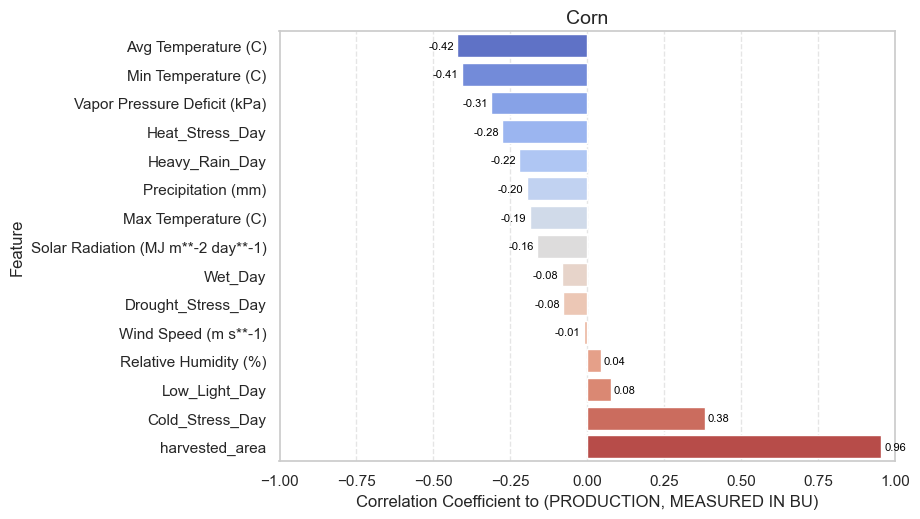

In [168]:
corn_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("CORN")
weather_corn_corr_dataframe = train_corn_dataset[corn_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_corn_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "Corn")

,"PRODUCTION, MEASURED IN BU"
0,8885000.0
1,4905000.0
2,3630000.0
3,6205000.0
4,6045000.0
...,...
1161,3536000.0
1162,272000.0
1163,12084000.0
1164,298000.0


#### 0.2 SOYBEANS CORR ANALYSIS

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31328\621277758.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


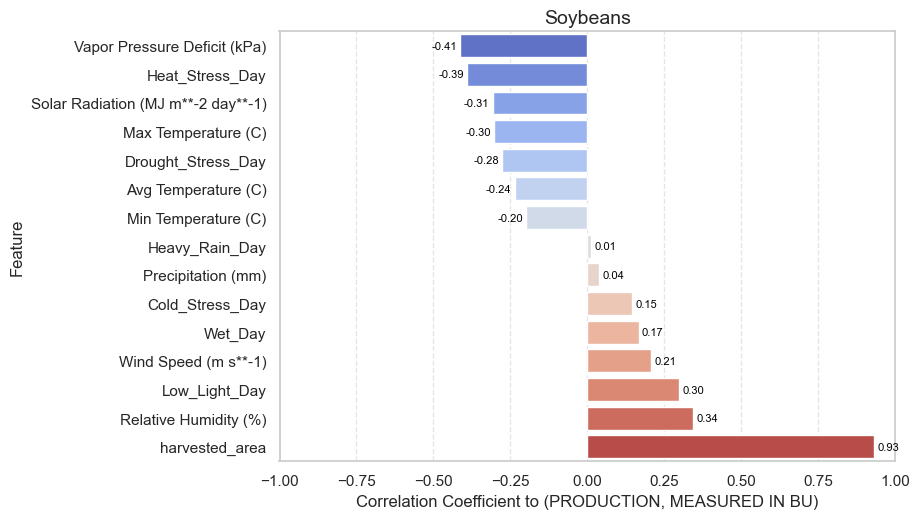

In [169]:
soybeans_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("SOYBEANS")
weather_soybeans_corr_dataframe = train_soybeans_dataset[soybeans_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_soybeans_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "Soybeans")

#### 0.3 COTTON CORR ANALYSIS

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31328\621277758.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


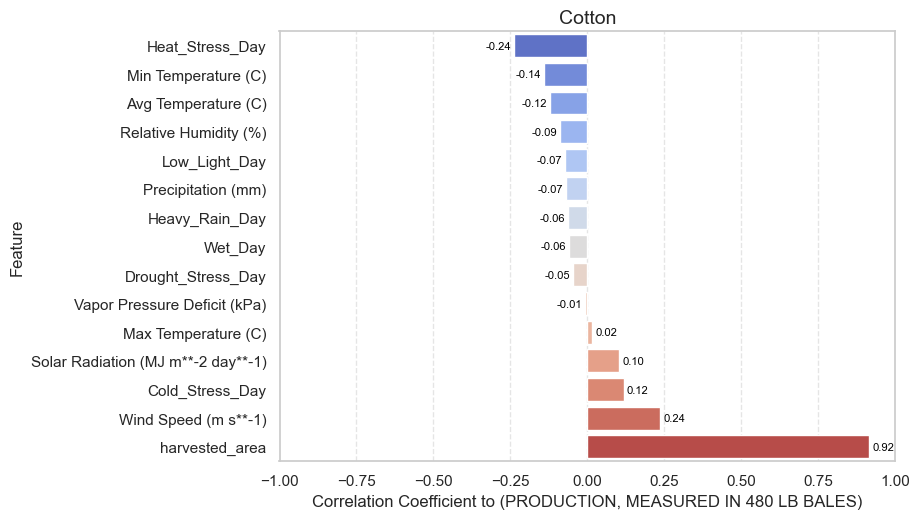

In [170]:
cotton_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("COTTON")
weather_cotton_corr_dataframe = train_cotton_dataset[cotton_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_cotton_corr_dataframe.corr(), "PRODUCTION, MEASURED IN 480 LB BALES", "Cotton")

#### 0.4 WHEAT CORR ANALYSIS

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31328\621277758.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


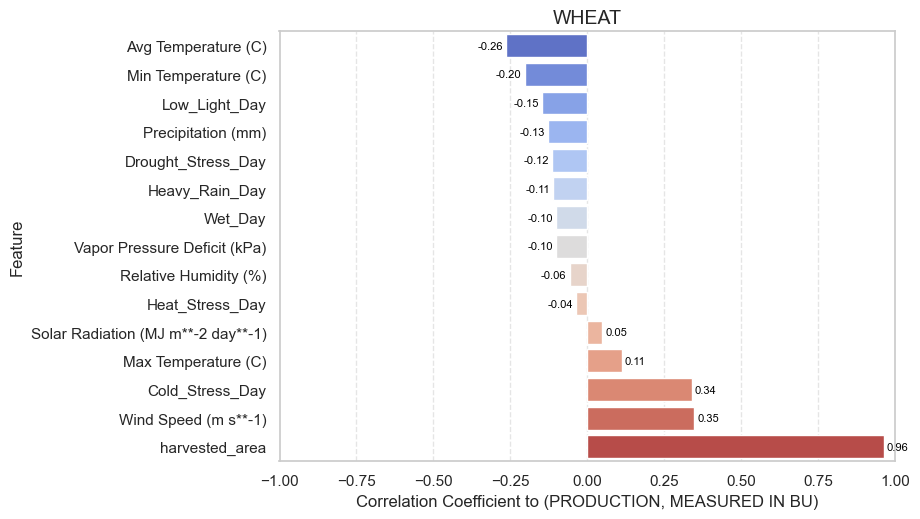

In [171]:
wheat_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("WHEAT")
weather_wheat_corr_dataframe = train_wheat_dataset[wheat_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_wheat_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "WHEAT")

In [163]:
corn_production = train_corn_dataset[['PRODUCTION, MEASURED IN BU']]
soybeans_production = train_soybeans_dataset[['PRODUCTION, MEASURED IN BU']]
cotton_production = train_cotton_dataset[['PRODUCTION, MEASURED IN 480 LB BALES']]
wheat_production = train_wheat_dataset[['PRODUCTION, MEASURED IN BU']]

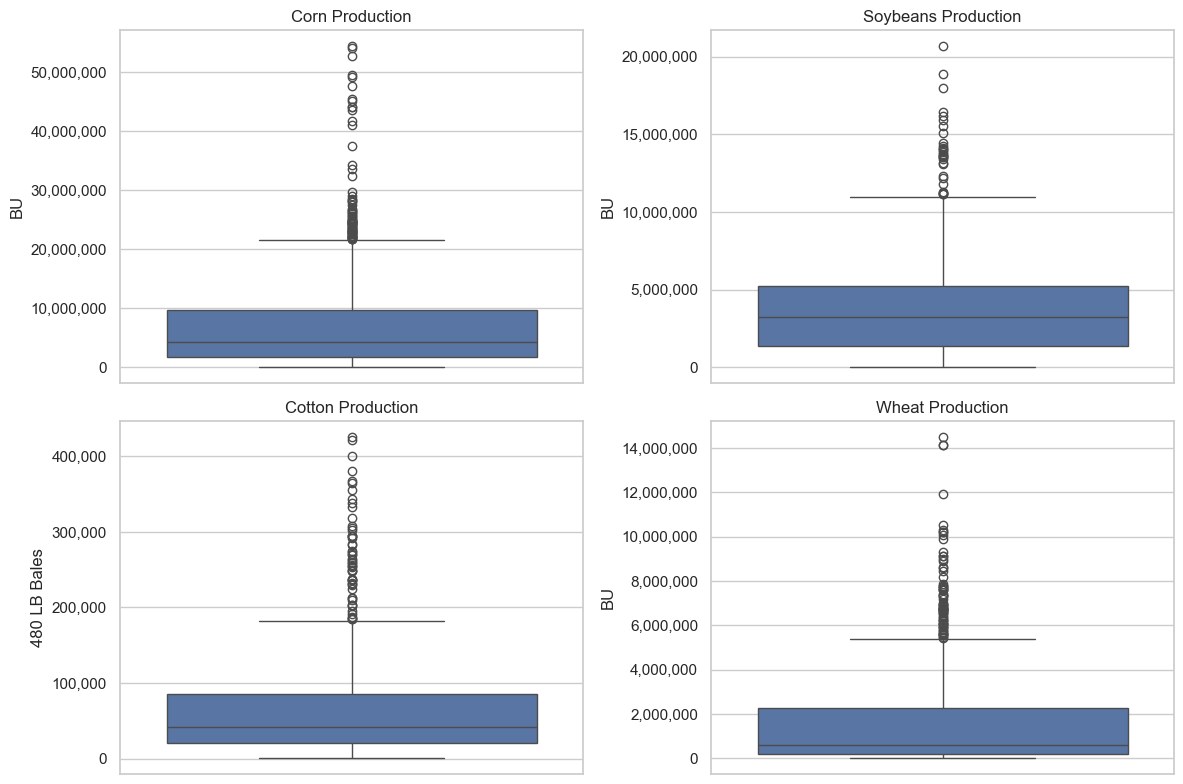

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Set the figure size and style
def comma_format(x, pos):
    return f'{int(x):,}'

formatter = FuncFormatter(comma_format)



# Set the figure size and style
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# First plot - Corn
plt.subplot(2, 2, 1)
sns.boxplot(y=corn_production['PRODUCTION, MEASURED IN BU'])
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Corn Production')
plt.ylabel('BU')

# Second plot - Soybeans
plt.subplot(2, 2, 2)
sns.boxplot(y=soybeans_production['PRODUCTION, MEASURED IN BU'])
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Soybeans Production')
plt.ylabel('BU')

# Third plot - Cotton
plt.subplot(2, 2, 3)
sns.boxplot(y=cotton_production['PRODUCTION, MEASURED IN 480 LB BALES'])
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Cotton Production')
plt.ylabel('480 LB Bales')

# Fourth plot - Wheat
plt.subplot(2, 2, 4)
sns.boxplot(y=wheat_production['PRODUCTION, MEASURED IN BU'])
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Wheat Production')
plt.ylabel('BU')

# Adjust layout
plt.tight_layout()

plt.savefig("crop_production_boxplots.png", dpi=300) 
plt.show()


---

In [11]:
sgd_param_grid = {
    'penalty': ['l2', 'l1'],
    'alpha': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1, 5],
    'learning_rate': ['constant'],
    'eta0': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
}

keys, values = zip(*sgd_param_grid.items())
sgd_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [12]:
svr_param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000],
    'epsilon': [0.1, 0.5, 1, 5, 10, 50],
    'gamma': ['scale']  # only used with RBF
}

keys, values = zip(*svr_param_grid.items())
raw_combinations = [dict(zip(keys, v)) for v in product(*values)]

# Filter gamma when kernel != 'rbf'
svr_param_combinations = [
    {k: v for k, v in combo.items() if not (k == 'gamma' and combo['kernel'] != 'rbf')}
    for combo in raw_combinations
]

In [13]:
svr_param_grid_log_transformed = {
    'kernel': ['linear', 'rbf'],
    'C': [1, 5, 10, 50, 100],
    'epsilon': [0.1, 0.5, 1, 5, 10, 50],
    'gamma': ['scale']  # only relevant for 'rbf'
}

# Generate all combinations
keys, values = zip(*svr_param_grid_log_transformed.items())
raw_combinations = [dict(zip(keys, v)) for v in product(*values)]

# Remove 'gamma' when kernel is not 'rbf'
svr_param_combinations_log_transformed = []
for combo in raw_combinations:
    if combo['kernel'] != 'rbf':
        combo.pop('gamma')
    svr_param_combinations_log_transformed.append(combo)


In [14]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Generate all combinations
keys, values = zip(*rf_param_grid.items())
rf_param_combinations = [dict(zip(keys, v)) for v in product(*values)]
print(len(rf_param_combinations))

324


In [15]:
mlp_param_grid = {
    'hidden_layer_sizes': [(50, 100, 50)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.01, 0.1, 1, 5],
    'learning_rate': ['constant'],      # only used with 'sgd'
    'learning_rate_init': [0.001, 0.01, 0.1, 0.5],
    'max_iter': [30000]
}

keys, values = zip(*mlp_param_grid.items())
mlp_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [ ]:
hgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 500, 1000, 5000],
    'max_depth': [None, 5, 10],
    'l2_regularization': [0.1, 0.5, 1.0, 5.0, 10.0],
    'min_samples_leaf': [20, 50]
}

keys, values = zip(*hgb_param_grid.items())
hgb_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

## 1. Corn Prediction

In [17]:
corn_target = 'PRODUCTION, MEASURED IN BU'

selected_columns_corn = [
    'Avg Temperature (C)',
    'Min Temperature (C)',
    'Cold_Stress_Day',
    'Vapor Pressure Deficit (kPa)',
    'Heat_Stress_Day',
    'harvested_area',
    'Year',
    corn_target,
]

In [18]:
merged_corn_dataset = pd.read_csv(merged_weather_and_corn_production_data_dir)

complete_corn_dataset = merged_corn_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
selected_features_corn_dataset = complete_corn_dataset[selected_columns_corn]
selected_features_corn_dataset

,Avg Temperature (C),Min Temperature (C),Cold_Stress_Day,Vapor Pressure Deficit (kPa),Heat_Stress_Day,harvested_area,Year,"PRODUCTION, MEASURED IN BU"
0,17.778272,-11.813784,127.891892,0.696802,5.567568,46203.848154,2017,8885000.0
1,18.603199,-8.312000,108.800000,0.683657,3.700000,25000.000000,2017,4905000.0
2,18.669693,-8.272000,100.933333,0.641058,1.200000,19901.315789,2017,3630000.0
3,16.135538,-11.329375,149.125000,0.616330,3.375000,30506.391347,2017,6205000.0
4,16.506291,-13.352500,141.375000,0.606205,2.312500,32605.177994,2017,6045000.0
...,...,...,...,...,...,...,...,...
1414,21.463896,-8.130303,88.181818,0.877018,66.939394,33903.095559,2022,2519000.0
1415,21.070175,-9.095333,91.466667,0.942296,70.200000,1948.504983,2022,117300.0
1416,20.884171,-8.440000,89.650000,0.798653,40.200000,85749.354005,2022,6637000.0
1417,20.250513,-10.844286,103.357143,1.105926,78.023810,83199.233716,2022,4343000.0


In [19]:
train_set_corn, test_set_corn = helper.split_dataset_by_year(selected_features_corn_dataset, 2022)
standard_scaler_corn = StandardScaler()

In [20]:
X_test_corn = test_set_corn.drop(columns=[corn_target])
y_test_corn = test_set_corn[corn_target]

In [21]:
precomputed_log_transformed_corn_data = helper.precompute_transformations_by_fold(
        train_set_corn, corn_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 1.1 SGD Regressor

#### 1.1.1 Standard Scaler Only

In [22]:
sgd_grid_search_results_corn = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_corn = max(sgd_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_sgd_corn['params'])
print("  Mean R²:", best_sgd_corn['mean_r2'])
print("  Mean MAE:", best_sgd_corn['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Corn Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.01, 'learning_rate': 'constant', 'eta0': 0.001}
  Mean R²: 0.9113750710210626
  Mean MAE: 1549099.2918622815


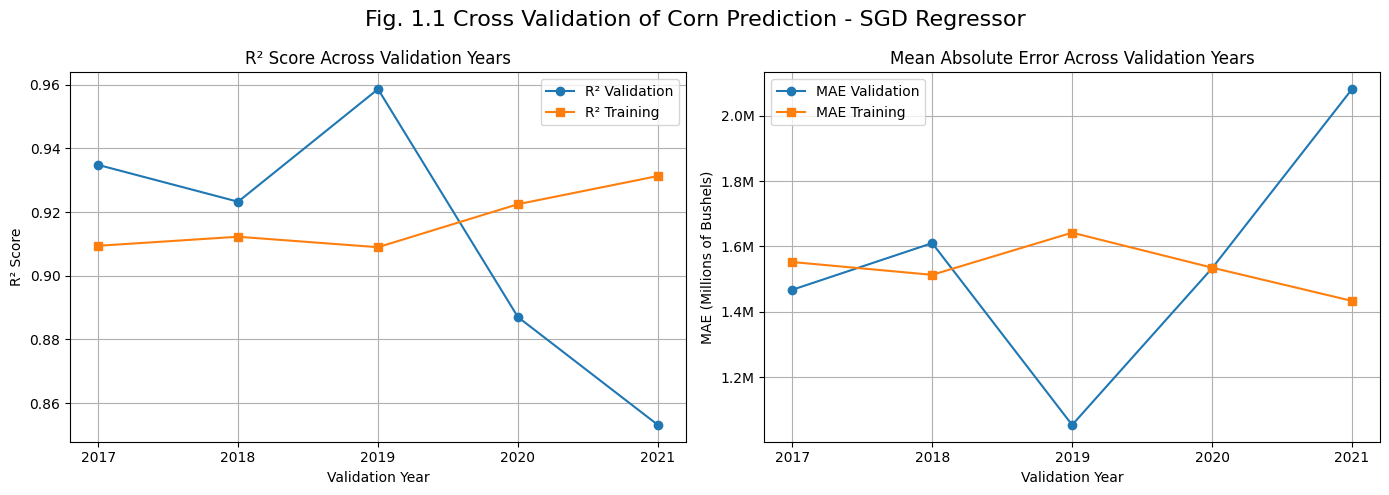

                                      Metric   Train Validation
0                               Avg R2 Score    0.92       0.91
1              Avg Mean Absolute Error (MAE)   1.54M      1.55M
2         Avg Root Mean Squared Error (RMSE)   2.30M      2.31M
3  Avg Mean Absolute Percentage Error (MAPE)  53.14%     52.99%
4                              Avg Max Error  11.97M     10.85M


In [118]:

corn_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SGD, title="Fig. 1.1 Cross Validation of Corn Prediction - SGD Regressor")

#### 1.1.2 Log Transformation + Standard Scaler

In [24]:
sgd_grid_search_results_corn_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, corn_target,
        scaler=standard_scaler_corn, model=model,
        verbose=False, max_safe_exp=100
    )
    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
    
best_sgd_corn_log_transformed = max(sgd_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_sgd_corn_log_transformed['params'])
print("  Mean R²:", best_sgd_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_corn_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Corn Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.01, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.9287907057044548
  Mean MAE: 1329382.3003183492


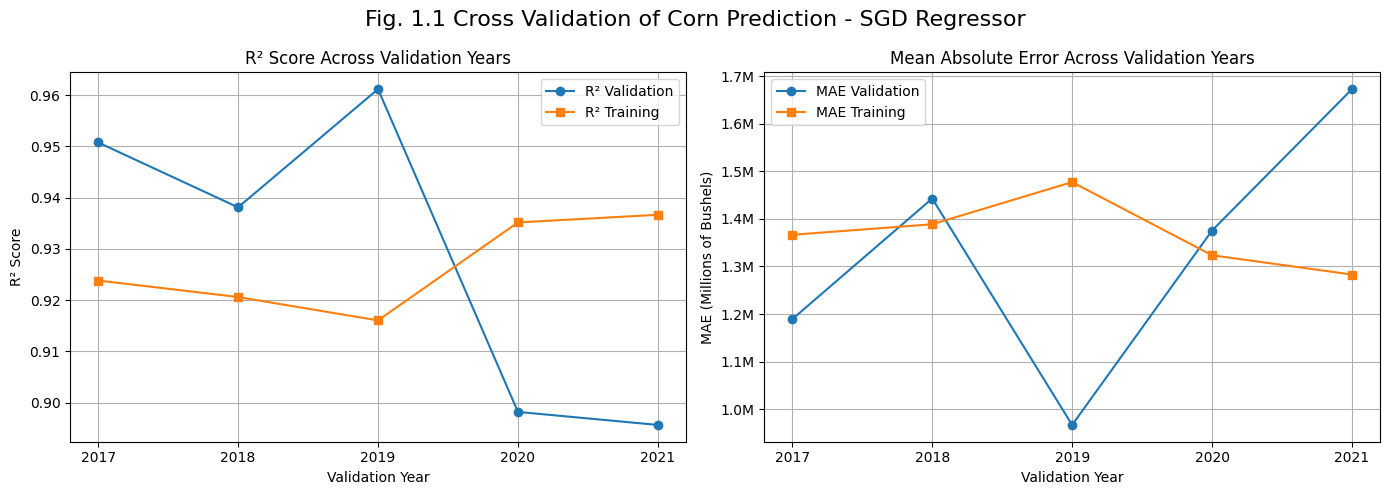

                                      Metric   Train Validation
0                               Avg R2 Score    0.93       0.93
1              Avg Mean Absolute Error (MAE)   1.37M      1.33M
2         Avg Root Mean Squared Error (RMSE)   2.16M      2.08M
3  Avg Mean Absolute Percentage Error (MAPE)  26.17%     26.20%
4                              Avg Max Error  12.43M      9.11M


In [119]:
corn_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        model=SGDRegressor(random_state=42, **best_sgd_corn_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 1.1 Cross Validation of Corn Prediction - SGD Regressor")

### 1.2 SVR Regressor

#### 1.2.1 Standard Scaler Only

In [26]:
svr_grid_search_results_corn = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_corn = max(svr_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Corn Prediction Grid Search Result")
print("  Best params:", best_svr_param_corn['params'])
print("  Mean R²:", best_svr_param_corn['mean_r2'])
print("  Mean MAE:", best_svr_param_corn['mean_mae'])


Grid Search Process: 144/144
SVR Corn Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 500000, 'epsilon': 0.1}
  Mean R²: 0.9118215943615009
  Mean MAE: 1532385.9798365287


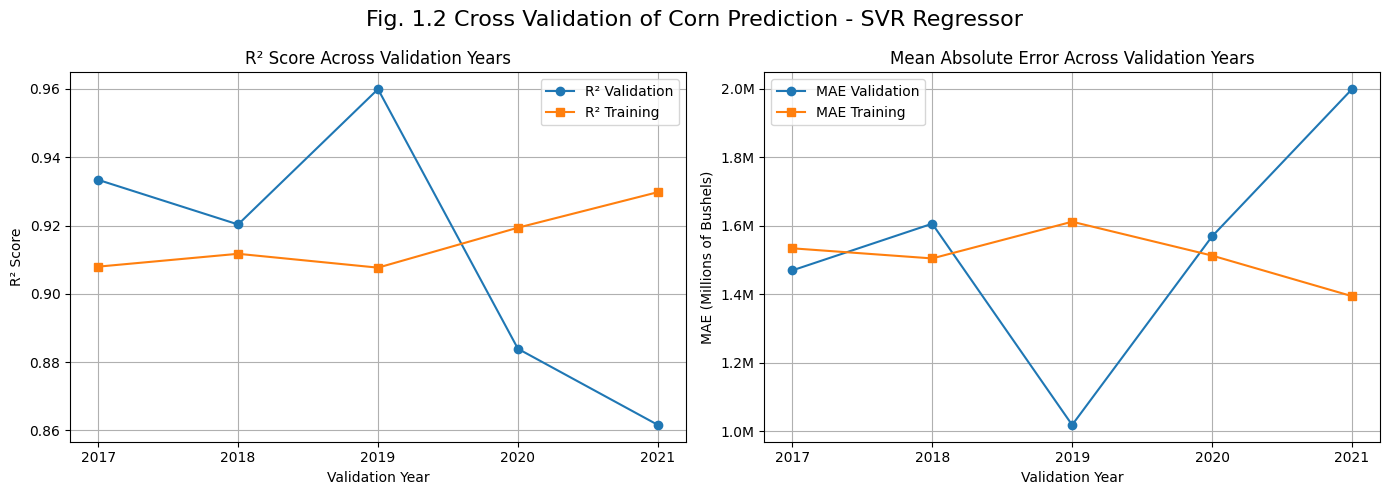

                                      Metric   Train Validation
0                               Avg R2 Score    0.92       0.91
1              Avg Mean Absolute Error (MAE)   1.51M      1.53M
2         Avg Root Mean Squared Error (RMSE)   2.32M      2.31M
3  Avg Mean Absolute Percentage Error (MAPE)  42.66%     44.39%
4                              Avg Max Error  12.73M     10.85M


In [120]:

corn_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn,
                                                                 model=SVR(**best_svr_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SVR, title="Fig. 1.2 Cross Validation of Corn Prediction - SVR Regressor")

#### 1.2.2 Log Transformation + Standard Scaler

In [28]:
svr_grid_search_results_corn_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_corn_log_transformed = max(svr_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Corn Prediction Grid Search Result")
print("  Best params:", best_svr_param_corn_log_transformed['params'])
print("  Mean R²:", best_svr_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_corn_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Corn Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
  Mean R²: 0.9308121851895113
  Mean MAE: 1180612.0608290925


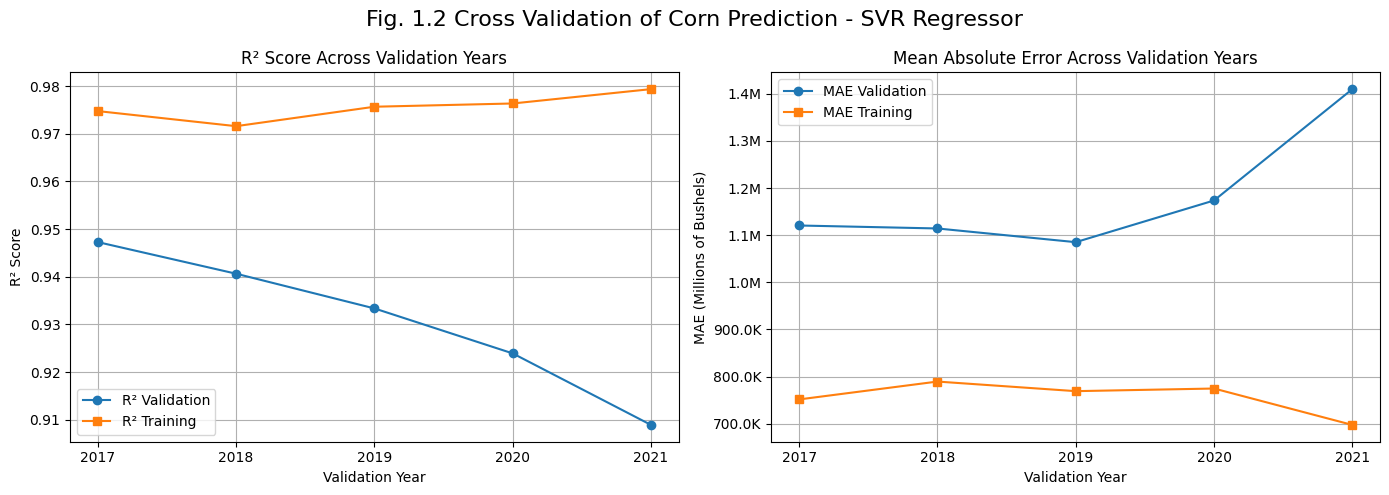

                                      Metric    Train Validation
0                               Avg R2 Score     0.98       0.93
1              Avg Mean Absolute Error (MAE)  756.27K      1.18M
2         Avg Root Mean Squared Error (RMSE)    1.25M      2.08M
3  Avg Mean Absolute Percentage Error (MAPE)   13.64%     21.32%
4                              Avg Max Error    6.75M     12.96M


In [121]:
corn_cross_val_training_result_complete_features_SVR = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_corn_data, 
    corn_target,
    scaler=standard_scaler_corn, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_corn_log_transformed['params']),
     
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SVR, title="Fig. 1.2 Cross Validation of Corn Prediction - SVR Regressor")

### 1.3 RF Regressor

#### 1.3.1 Standard Scaler Only

In [30]:
rf_grid_search_results_corn = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_corn = max(rf_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Corn Prediction Grid Search Result")
print("  Best params:", best_rf_param_corn['params'])
print("  Mean R²:", best_rf_param_corn['mean_r2'])
print("  Mean MAE:", best_rf_param_corn['mean_mae'])

Grid Search Process: 324/324
Random Forest Corn Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}
  Mean R²: 0.942609436898094
  Mean MAE: 1088105.2933701512


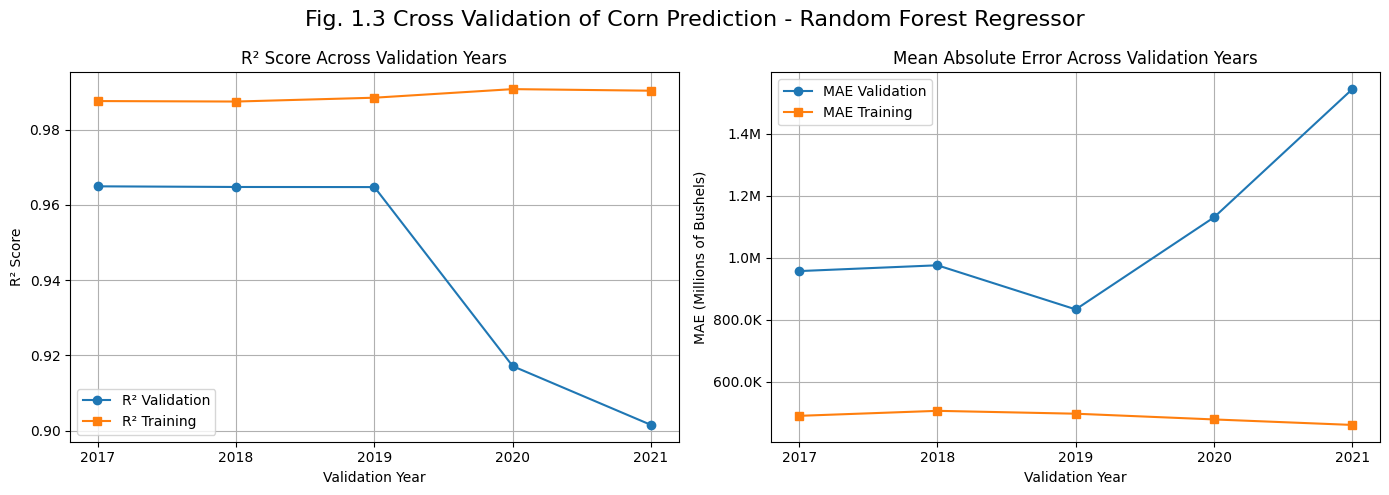

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.94
1              Avg Mean Absolute Error (MAE)  486.35K      1.09M
2         Avg Root Mean Squared Error (RMSE)  837.74K      1.84M
3  Avg Mean Absolute Percentage Error (MAPE)   10.55%     22.53%
4                              Avg Max Error    6.91M     11.69M


In [122]:

corn_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_RF, title="Fig. 1.3 Cross Validation of Corn Prediction - Random Forest Regressor")

#### 1.3.2 Log Transformation + Standard Scaler

In [32]:
rf_grid_search_results_corn_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_corn_log_transformed = max(rf_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Corn Prediction Grid Search Result")
print("  Best params:", best_rf_param_corn_log_transformed['params'])
print("  Mean R²:", best_rf_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_corn_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Corn Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}
  Mean R²: 0.9437555328407713
  Mean MAE: 1088704.8882848932


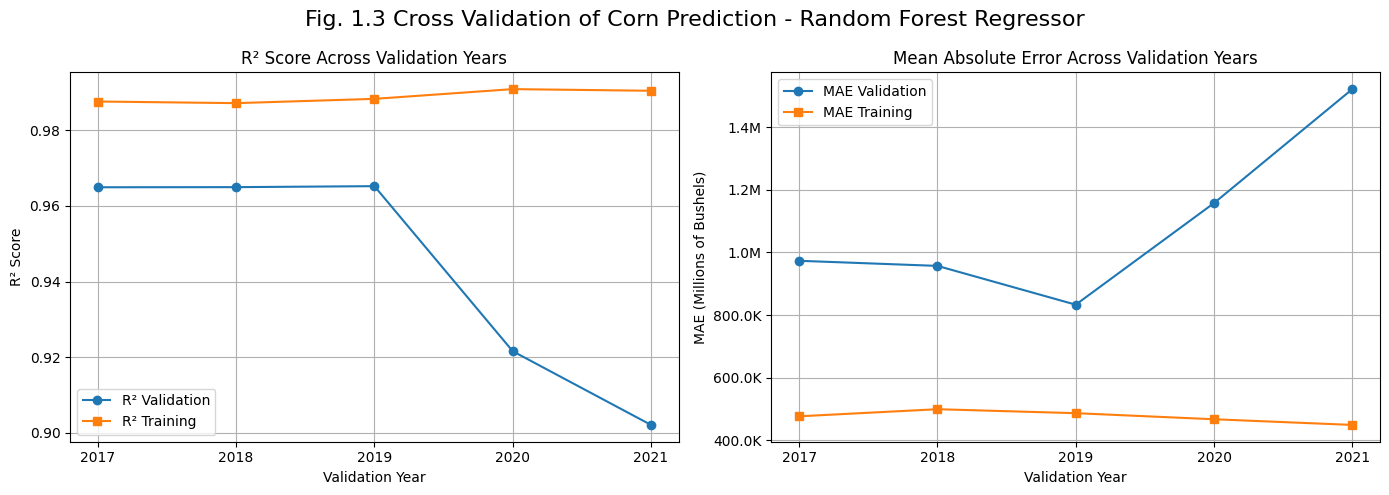

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.94
1              Avg Mean Absolute Error (MAE)  475.99K      1.09M
2         Avg Root Mean Squared Error (RMSE)  840.95K      1.82M
3  Avg Mean Absolute Percentage Error (MAPE)    9.25%     21.55%
4                              Avg Max Error    7.04M     11.77M


In [123]:
corn_cross_val_training_result_complete_features_RF = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_corn_data, 
    corn_target,
    scaler=standard_scaler_corn, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_corn_log_transformed['params']),
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_RF, title="Fig. 1.3 Cross Validation of Corn Prediction - Random Forest Regressor")

### 1.4 MLP Regressor

#### 1.4.1 Standard Scaler Only

In [34]:
mlp_grid_search_results_corn = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_corn = max(mlp_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_mlp_param_corn['params'])
print("  Mean R²:", best_mlp_param_corn['mean_r2'])
print("  Mean MAE:", best_mlp_param_corn['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Corn Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_iter': 30000}
  Mean R²: 0.9417774290619919
  Mean MAE: 1166290.3523984787


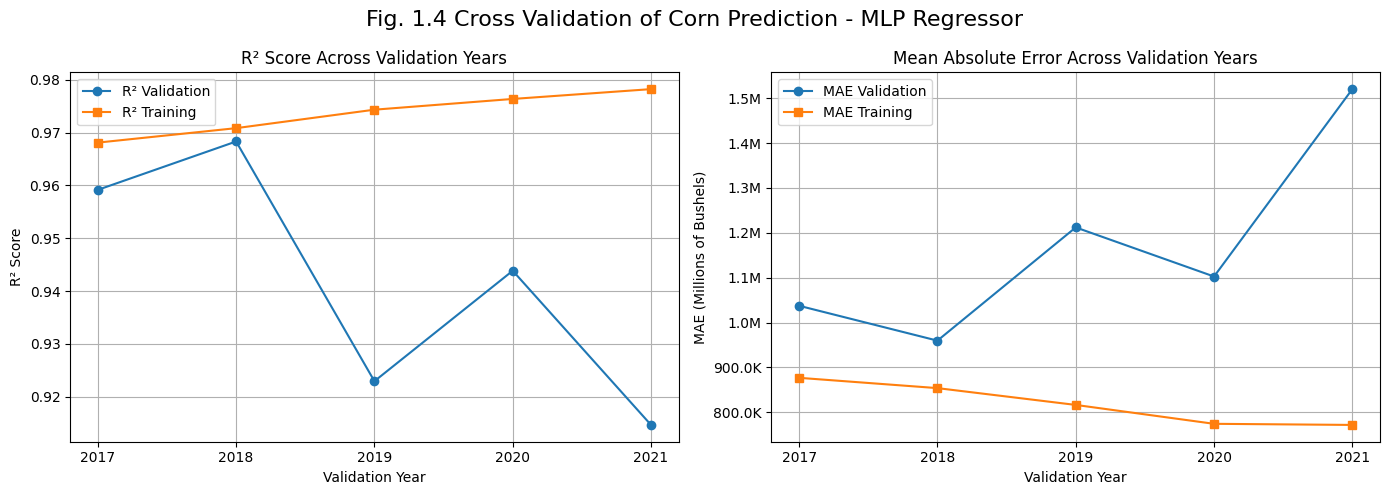

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.94
1              Avg Mean Absolute Error (MAE)  818.62K      1.17M
2         Avg Root Mean Squared Error (RMSE)    1.29M      1.87M
3  Avg Mean Absolute Percentage Error (MAPE)   25.67%     32.11%
4                              Avg Max Error    8.37M      8.70M


In [124]:

corn_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_MLP, title="Fig. 1.4 Cross Validation of Corn Prediction - MLP Regressor")

#### 1.4.2 Log Transformation + Standard Scaler

In [36]:
mlp_grid_search_results_corn_log_transformed = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1
best_mlp_param_corn_log_transformed = max(mlp_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))

print()
print("MLPRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_mlp_param_corn_log_transformed['params'])
print("  Mean R²:", best_mlp_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_corn_log_transformed['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Corn Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.9259575612686202
  Mean MAE: 1226544.91292557


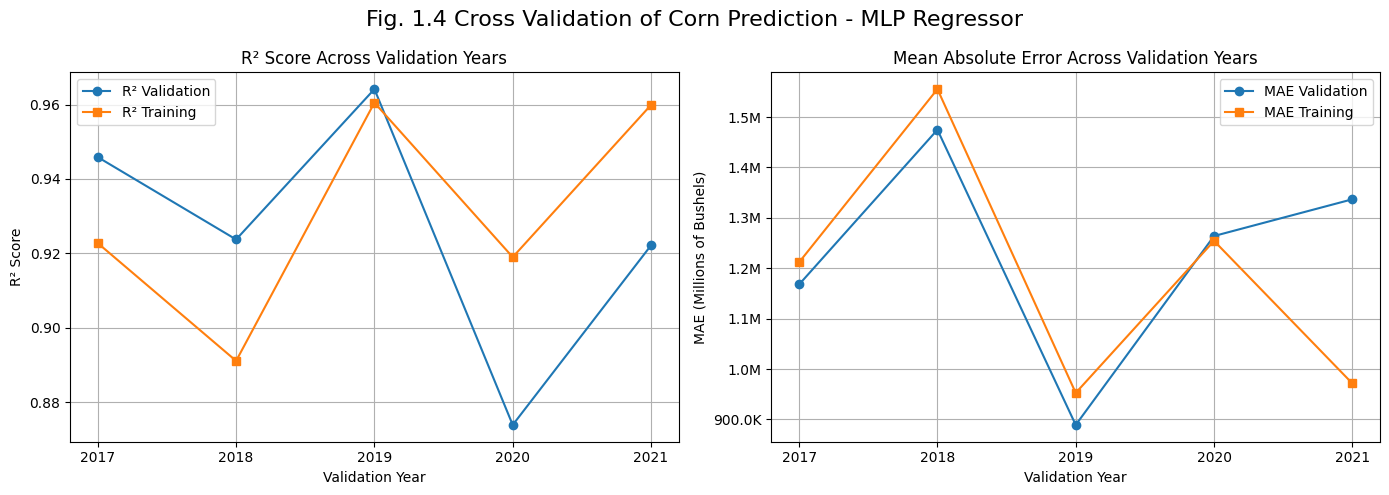

                                      Metric   Train Validation
0                               Avg R2 Score    0.93       0.93
1              Avg Mean Absolute Error (MAE)   1.19M      1.23M
2         Avg Root Mean Squared Error (RMSE)   2.06M      2.11M
3  Avg Mean Absolute Percentage Error (MAPE)  20.57%     21.59%
4                              Avg Max Error  14.51M     11.30M


In [125]:

corn_cross_val_training_result_complete_features_MLP = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_corn_log_transformed['params'])
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_MLP, title="Fig. 1.4 Cross Validation of Corn Prediction - MLP Regressor")

### 1.5 HGBoost Regressor

#### 1.5.1 Standard Scaler Only

In [102]:
hgb_grid_search_results_corn = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_corn = max(hgb_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Corn Prediction Grid Search Result")
print("  Best params:", best_hgb_param_corn['params'])
print("  Mean R²:", best_hgb_param_corn['mean_r2'])
print("  Mean MAE:", best_hgb_param_corn['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Corn Prediction Grid Search Result
  Best params: {'learning_rate': 0.01, 'max_iter': 500, 'max_depth': 5, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.9184192740945554
  Mean MAE: 1234928.5562248968


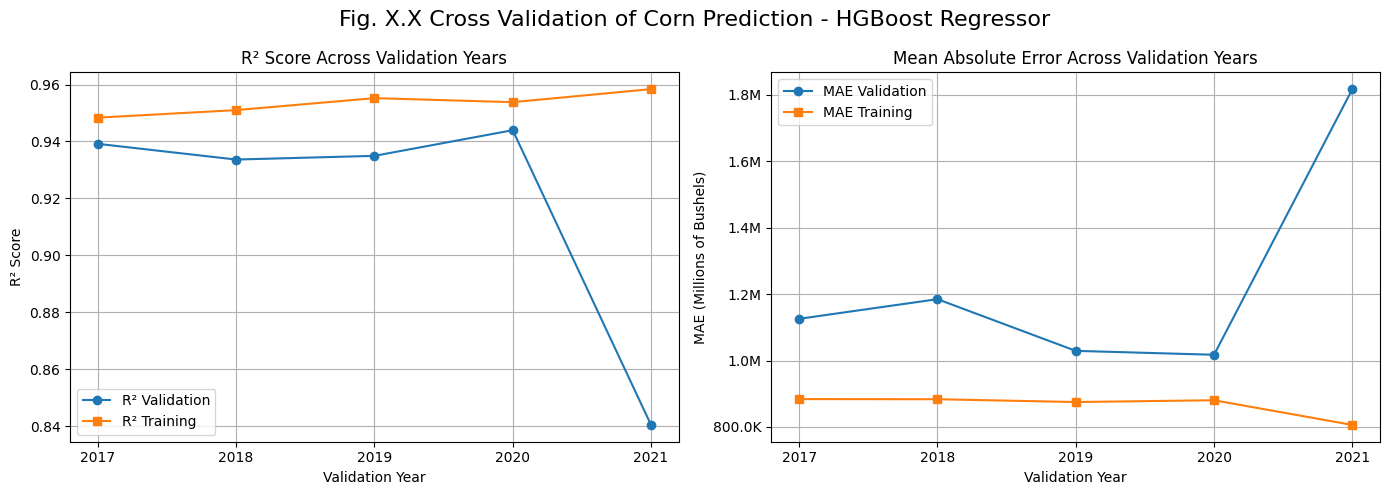

                                      Metric    Train Validation
0                               Avg R2 Score     0.95       0.92
1              Avg Mean Absolute Error (MAE)  865.76K      1.23M
2         Avg Root Mean Squared Error (RMSE)    1.72M      2.23M
3  Avg Mean Absolute Percentage Error (MAPE)   27.21%     35.25%
4                              Avg Max Error   15.08M     15.21M


In [126]:
corn_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Corn Prediction - HGBoost Regressor")

#### 1.5.2 Log Transformation + Standard Scaler

In [104]:
hgb_grid_search_results_corn_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_corn_log_transformed = max(hgb_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Corn Prediction Grid Search Result")
print("  Best params:", best_hgb_param_corn_log_transformed['params'])
print("  Mean R²:", best_hgb_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_corn_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Corn Prediction Grid Search Result
  Best params: {'learning_rate': 0.01, 'max_iter': 1000, 'max_depth': 5, 'l2_regularization': 0.1, 'min_samples_leaf': 20}
  Mean R²: 0.9234923664058499
  Mean MAE: 1161370.7846920744


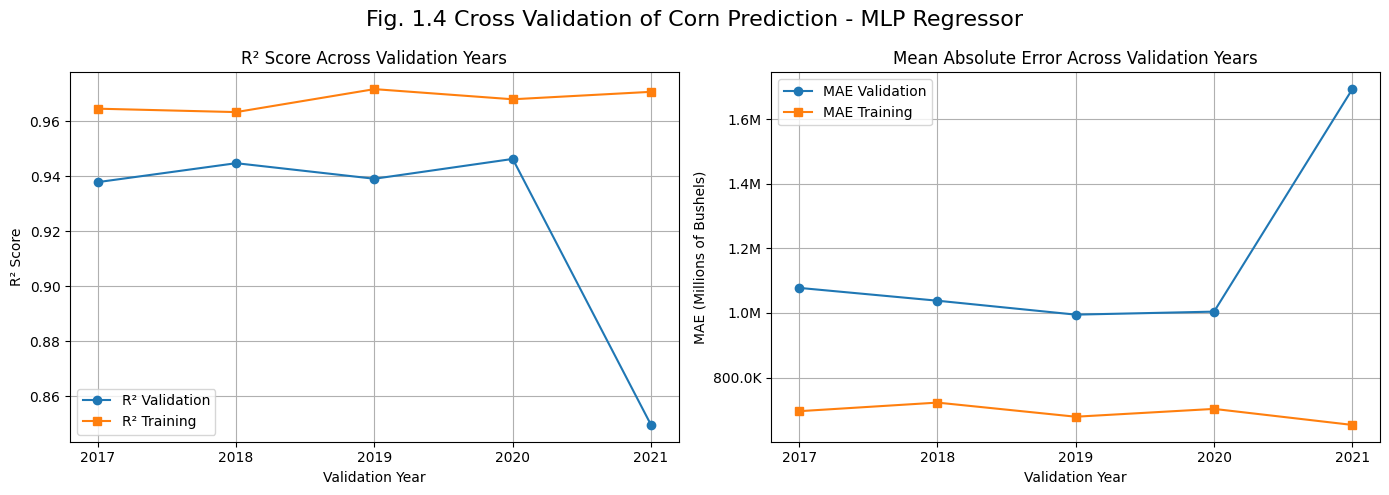

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.92
1              Avg Mean Absolute Error (MAE)  690.66K      1.16M
2         Avg Root Mean Squared Error (RMSE)    1.43M      2.15M
3  Avg Mean Absolute Percentage Error (MAPE)   11.02%     20.78%
4                              Avg Max Error   12.82M     14.16M


In [127]:
corn_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_corn_log_transformed['params'])
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. 1.4 Cross Validation of Corn Prediction - MLP Regressor")

## 2. Soybeans Prediction

In [38]:
soybeans_target = 'PRODUCTION, MEASURED IN BU'

soybeans_selected_columns = [
    'Max Temperature (C)',
    'Vapor Pressure Deficit (kPa)',
    'Heat_Stress_Day',
    'Relative Humidity (%)',
    'Solar Radiation (MJ m**-2 day**-1)',
    'Low_Light_Day',
    soybeans_target,
    'harvested_area',
    'Year'
]

In [39]:
merged_soybeans_dataset = pd.read_csv(merged_weather_and_soybeans_production_data_dir)

complete_soybeans_dataset = merged_soybeans_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
selected_features_soybeans_dataset = complete_soybeans_dataset[soybeans_selected_columns]
selected_features_soybeans_dataset

,Max Temperature (C),Vapor Pressure Deficit (kPa),Heat_Stress_Day,Relative Humidity (%),Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,"PRODUCTION, MEASURED IN BU",harvested_area,Year
0,35.917027,0.696802,5.567568,71.964857,126087.217712,5.918919,10040000.0,186964.618250,2017
1,35.795500,0.683657,3.700000,73.309178,122775.899299,11.200000,3490000.0,61443.661972,2017
2,35.024000,0.641058,1.200000,74.422411,127958.411779,9.200000,8647000.0,168886.718750,2017
3,35.586250,0.616330,3.375000,72.694829,130721.404219,7.687500,6583000.0,120127.737226,2017
4,35.128667,0.613917,2.666667,73.269534,127231.905283,10.933333,745000.0,18908.629442,2017
...,...,...,...,...,...,...,...,...,...
1075,41.462083,1.068879,67.250000,61.609943,148098.711053,18.625000,63000.0,3750.000000,2022
1076,41.040800,1.004137,64.800000,63.513699,145956.933936,18.640000,110000.0,9166.666667,2022
1077,42.690000,1.222846,60.150000,48.896740,165870.188381,12.100000,139000.0,3492.462312,2022
1078,39.329394,0.877018,66.939394,71.104193,148370.152427,18.606061,34500.0,2379.310345,2022


In [40]:
train_set_soybeans, test_set_soybeans = helper.split_dataset_by_year(selected_features_soybeans_dataset, 2022)
standard_scaler_soybeans = StandardScaler()

In [41]:
X_test_soybeans = test_set_soybeans.drop(columns=[soybeans_target])
y_test_soybeans = test_set_soybeans[soybeans_target]

In [42]:
precomputed_log_transformed_soybeans_data = helper.precompute_transformations_by_fold(
        train_set_soybeans, soybeans_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 2.1 SGD Regressor

#### 2.1.1 Standard Scaler Only

In [43]:
sgd_grid_search_results_soybeans = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_soybeans = max(sgd_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_sgd_soybeans['params'])
print("  Mean R²:", best_sgd_soybeans['mean_r2'])
print("  Mean MAE:", best_sgd_soybeans['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Soybeans Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.005, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.8652753210689139
  Mean MAE: 796798.0458721165


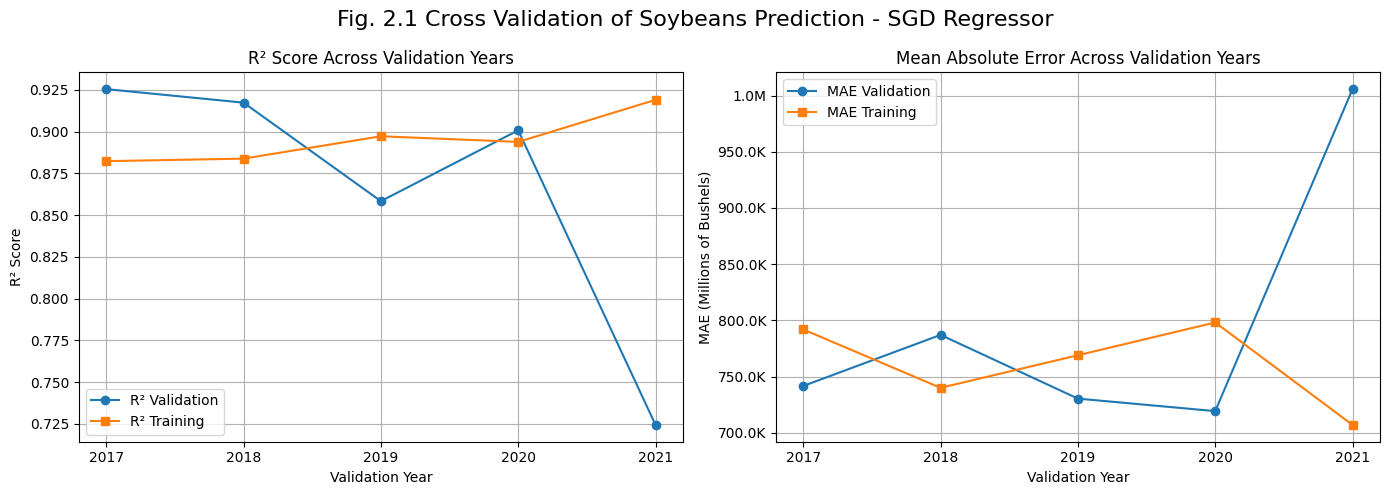

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.87
1              Avg Mean Absolute Error (MAE)  761.17K    796.80K
2         Avg Root Mean Squared Error (RMSE)    1.02M      1.08M
3  Avg Mean Absolute Percentage Error (MAPE)  104.39%     99.98%
4                              Avg Max Error    5.28M      4.34M


In [128]:
soybeans_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SGD, title="Fig. 2.1 Cross Validation of Soybeans Prediction - SGD Regressor")

#### 2.1.2 Log Transformation + Standard Scaler 

In [45]:
sgd_grid_search_results_soybeans_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, soybeans_target,
        scaler=standard_scaler_soybeans, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_soybeans_log_transformed = max(sgd_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_sgd_soybeans_log_transformed['params'])
print("  Mean R²:", best_sgd_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_soybeans_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Soybeans Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.005}
  Mean R²: 0.8605358790904944
  Mean MAE: 758643.4000701741


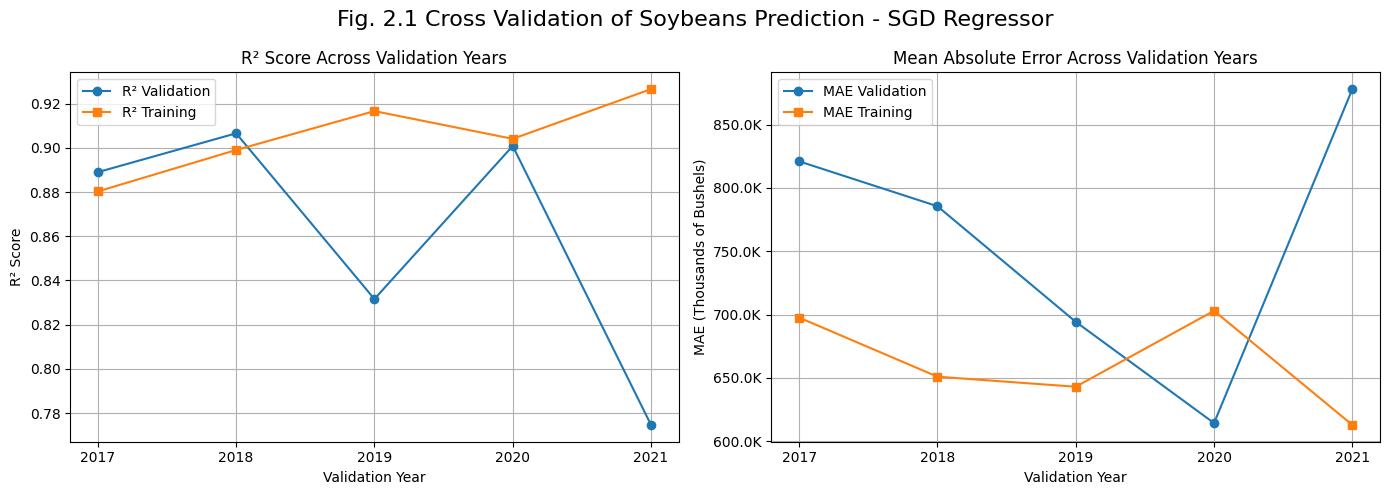

                                      Metric    Train Validation
0                               Avg R2 Score     0.91       0.86
1              Avg Mean Absolute Error (MAE)  661.45K    758.64K
2         Avg Root Mean Squared Error (RMSE)  967.36K      1.12M
3  Avg Mean Absolute Percentage Error (MAPE)   23.48%     25.70%
4                              Avg Max Error    5.23M      4.80M


In [129]:
soybeans_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        model=SGDRegressor(random_state=42, **best_sgd_soybeans_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 2.1 Cross Validation of Soybeans Prediction - SGD Regressor")

### 2.2 SVR Regressor

#### 2.2.1 Standard Scaler Only

In [47]:
svr_grid_search_results_soybeans = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_soybeans = max(svr_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Soybeans Prediction Grid Search Result")
print("  Best params:", best_svr_param_soybeans['params'])
print("  Mean R²:", best_svr_param_soybeans['mean_r2'])
print("  Mean MAE:", best_svr_param_soybeans['mean_mae'])


Grid Search Process: 144/144
SVR Soybeans Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 50000, 'epsilon': 0.1}
  Mean R²: 0.8593255589433134
  Mean MAE: 792829.7355260014


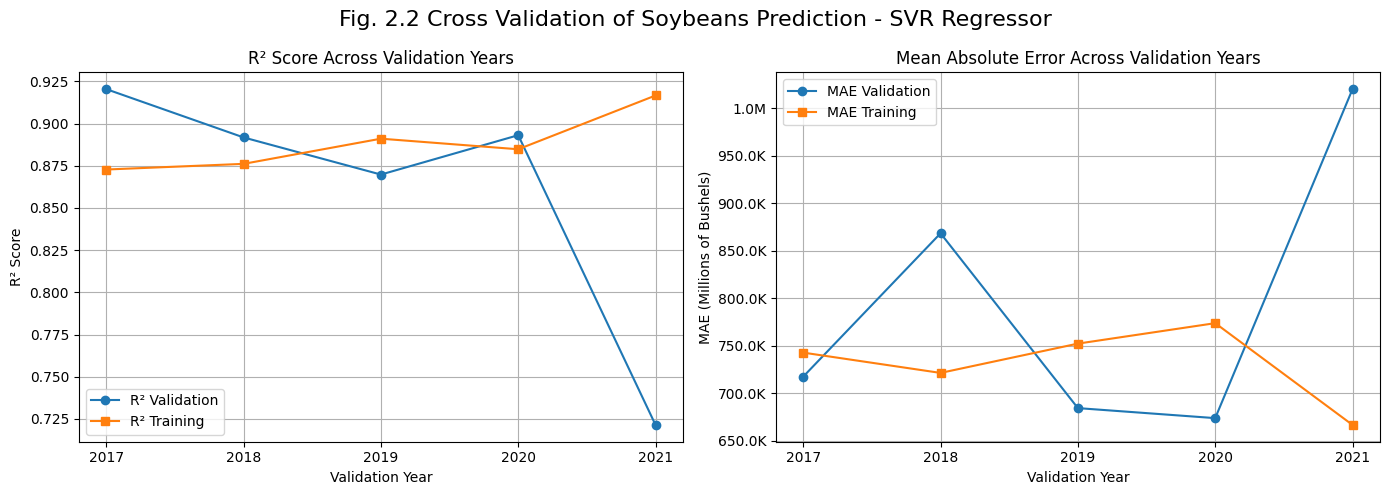

                                      Metric    Train Validation
0                               Avg R2 Score     0.89       0.86
1              Avg Mean Absolute Error (MAE)  731.30K    792.83K
2         Avg Root Mean Squared Error (RMSE)    1.05M      1.12M
3  Avg Mean Absolute Percentage Error (MAPE)   62.03%     69.23%
4                              Avg Max Error    5.19M      4.48M


In [130]:
soybeans_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans,
                                                                 model=SVR(**best_svr_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SVR, title="Fig. 2.2 Cross Validation of Soybeans Prediction - SVR Regressor")

#### 2.2.2 Log Transformation + Standard Scaler 

In [49]:
svr_grid_search_results_soybeans_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_soybeans_log_transformed = max(svr_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Soybeans Prediction Grid Search Result")
print("  Best params:", best_svr_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_svr_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_soybeans_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Soybeans Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 1, 'epsilon': 0.1}
  Mean R²: 0.8664760404223794
  Mean MAE: 695606.5914195945


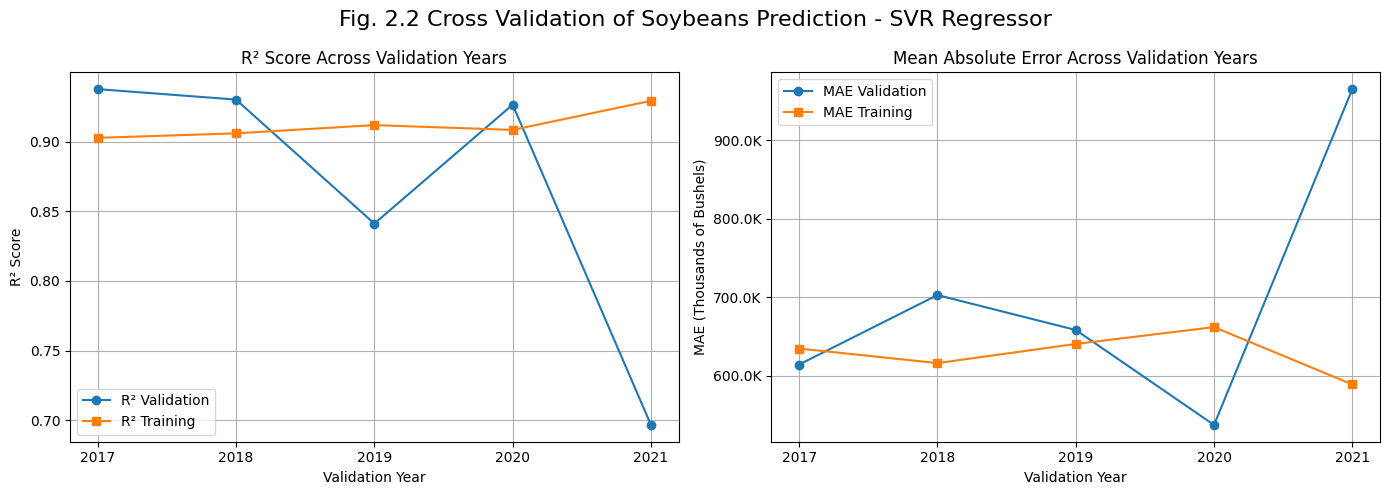

                                      Metric    Train Validation
0                               Avg R2 Score     0.91       0.87
1              Avg Mean Absolute Error (MAE)  628.57K    695.61K
2         Avg Root Mean Squared Error (RMSE)  936.95K      1.05M
3  Avg Mean Absolute Percentage Error (MAPE)   22.41%     24.18%
4                              Avg Max Error    5.24M      4.55M


In [131]:
soybeans_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_soybeans_data, 
    soybeans_target,
    scaler=standard_scaler_soybeans, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_soybeans_log_transformed['params']), 
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 2.2 Cross Validation of Soybeans Prediction - SVR Regressor")

### 2.3 Random Forest Regressor

#### 2.3.1 Standard Scaler Only

In [51]:
rf_grid_search_results_soybeans = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_soybeans = max(rf_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Soybeans Prediction Grid Search Result")
print("  Best params:", best_rf_param_soybeans['params'])
print("  Mean R²:", best_rf_param_soybeans['mean_r2'])
print("  Mean MAE:", best_rf_param_soybeans['mean_mae'])

Grid Search Process: 324/324
Random Forest Soybeans Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.862544981660401
  Mean MAE: 745532.3630076363


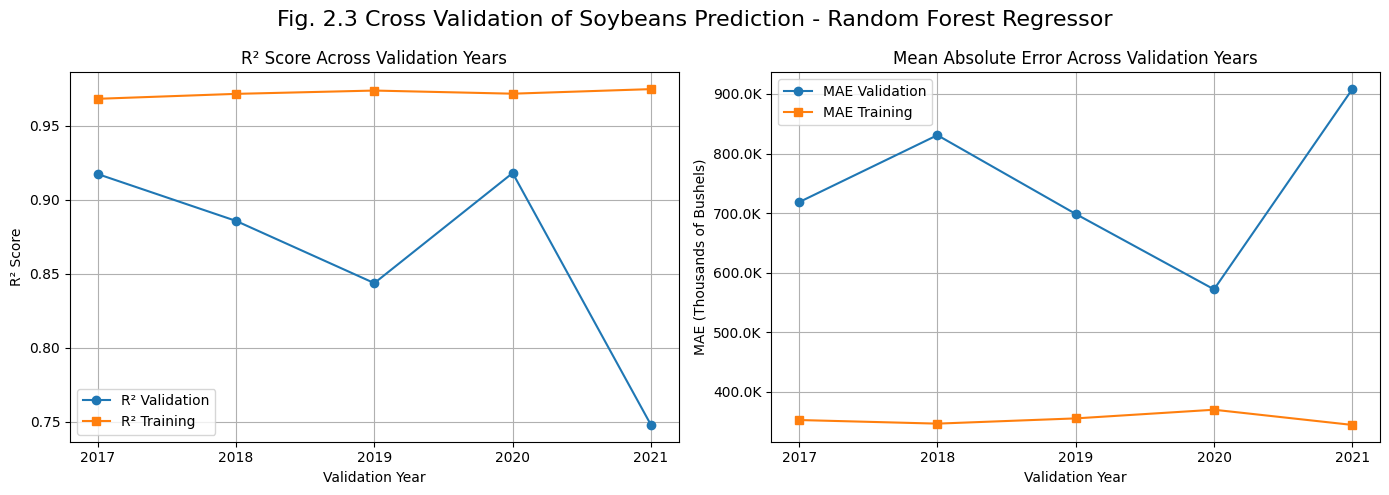

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.86
1              Avg Mean Absolute Error (MAE)  353.72K    745.53K
2         Avg Root Mean Squared Error (RMSE)  526.88K      1.11M
3  Avg Mean Absolute Percentage Error (MAPE)   13.36%     28.62%
4                              Avg Max Error    3.05M      4.60M


In [132]:
soybeans_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_RF, title="Fig. 2.3 Cross Validation of Soybeans Prediction - Random Forest Regressor")

#### 2.3.1 Log Transformation + Standard Scaler

In [53]:
rf_grid_search_results_soybeans_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_soybeans_log_transformed = max(rf_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Soybeans Prediction Grid Search Result")
print("  Best params:", best_rf_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_rf_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Soybeans Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None}
  Mean R²: 0.8660588761709522
  Mean MAE: 741450.9228190046


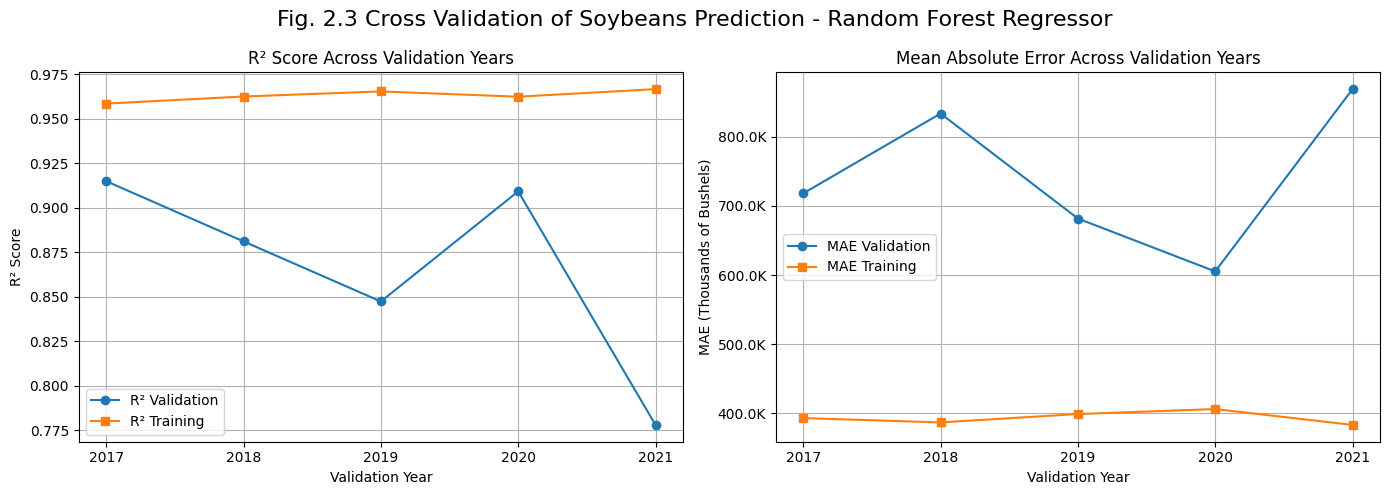

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.87
1              Avg Mean Absolute Error (MAE)  393.85K    741.45K
2         Avg Root Mean Squared Error (RMSE)  606.16K      1.10M
3  Avg Mean Absolute Percentage Error (MAPE)   13.64%     25.95%
4                              Avg Max Error    4.60M      4.96M


In [133]:
soybeans_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_soybeans_data, 
    soybeans_target,
    scaler=standard_scaler_soybeans, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_soybeans_log_transformed['params']),
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 2.3 Cross Validation of Soybeans Prediction - Random Forest Regressor")

### 2.4 MLP Regressor

#### 2.4.1 Standard Scaler Only

In [55]:
mlp_grid_search_results_soybeans = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_soybeans = max(mlp_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_mlp_param_soybeans['params'])
print("  Mean R²:", best_mlp_param_soybeans['mean_r2'])
print("  Mean MAE:", best_mlp_param_soybeans['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Soybeans Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.01, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 30000}
  Mean R²: 0.8804652008532019
  Mean MAE: 749509.6328683604


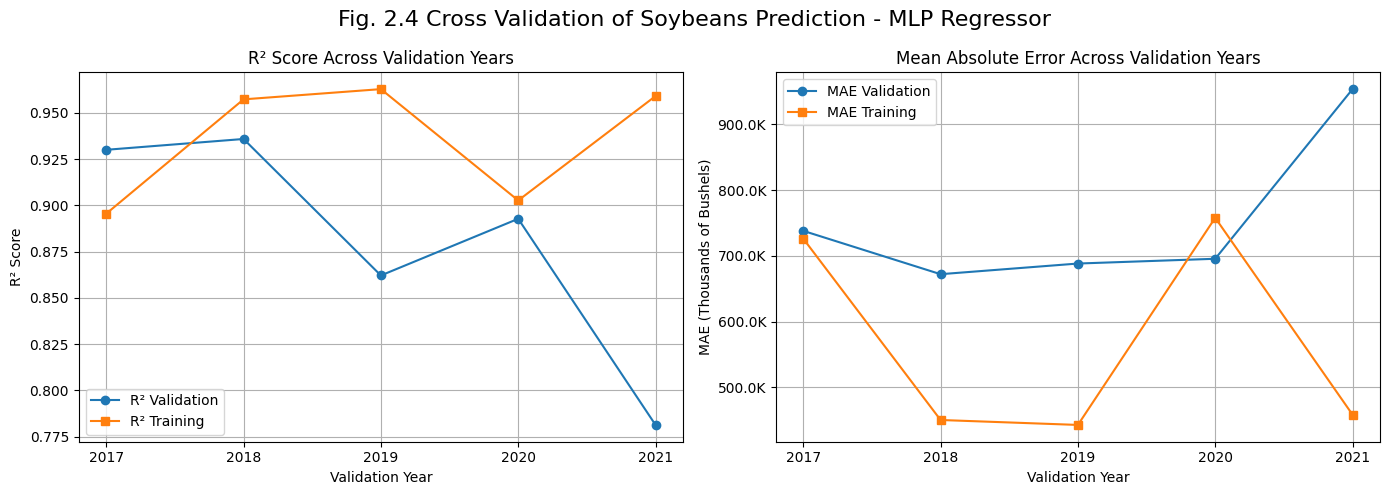

                                      Metric    Train Validation
0                               Avg R2 Score     0.94       0.88
1              Avg Mean Absolute Error (MAE)  567.16K    749.51K
2         Avg Root Mean Squared Error (RMSE)  780.99K      1.02M
3  Avg Mean Absolute Percentage Error (MAPE)   59.30%     84.00%
4                              Avg Max Error    3.95M      3.79M


In [134]:
soybeans_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_MLP, title="Fig. 2.4 Cross Validation of Soybeans Prediction - MLP Regressor")

#### 2.4.2 Log Transformation + Standard Scaler 

In [57]:
mlp_grid_search_results_soybeans_log_transformed = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_soybeans_log_transformed = max(mlp_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_mlp_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_mlp_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Soybeans Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 30000}
  Mean R²: 0.8789672413223804
  Mean MAE: 701813.5407335719


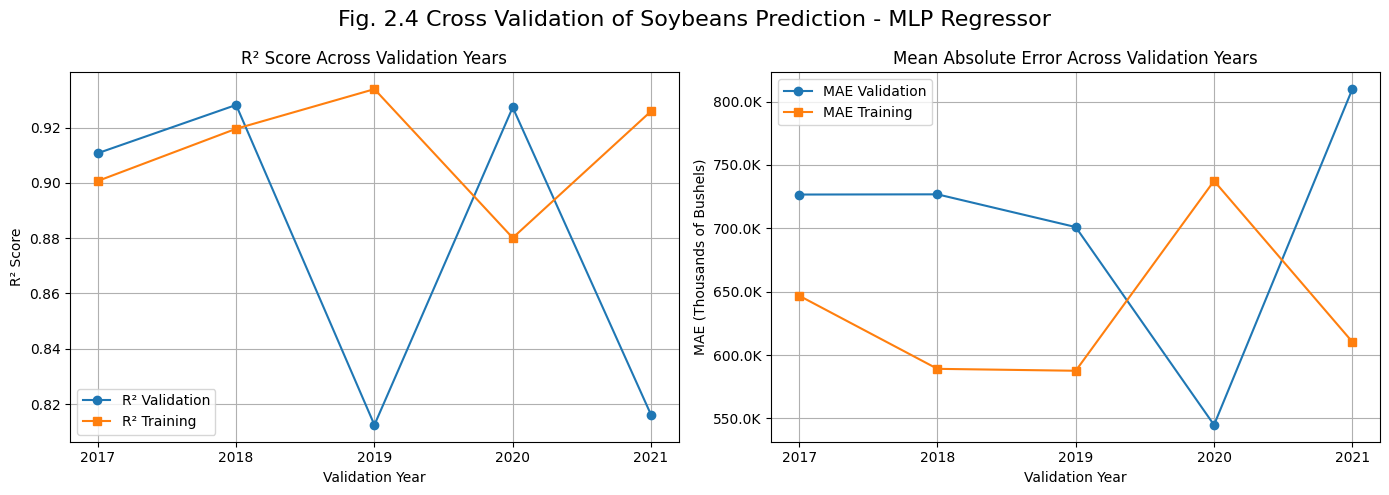

                                      Metric    Train Validation
0                               Avg R2 Score     0.91       0.88
1              Avg Mean Absolute Error (MAE)  634.28K    701.81K
2         Avg Root Mean Squared Error (RMSE)  931.92K      1.03M
3  Avg Mean Absolute Percentage Error (MAPE)   20.49%     24.04%
4                              Avg Max Error    5.23M      4.50M


In [135]:
soybeans_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_soybeans_log_transformed['params'])
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 2.4 Cross Validation of Soybeans Prediction - MLP Regressor")

### 2.5 HGBoost Regressor

#### 2.5.1 Standard Scaler Only

In [106]:
hgb_grid_search_results_soybeans = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_soybeans = max(hgb_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_hgb_param_soybeans['params'])
print("  Mean R²:", best_hgb_param_soybeans['mean_r2'])
print("  Mean MAE:", best_hgb_param_soybeans['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Soybeans Prediction Grid Search Result
  Best params: {'learning_rate': 0.01, 'max_iter': 500, 'max_depth': 5, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.8539971252885371
  Mean MAE: 747548.9568163666


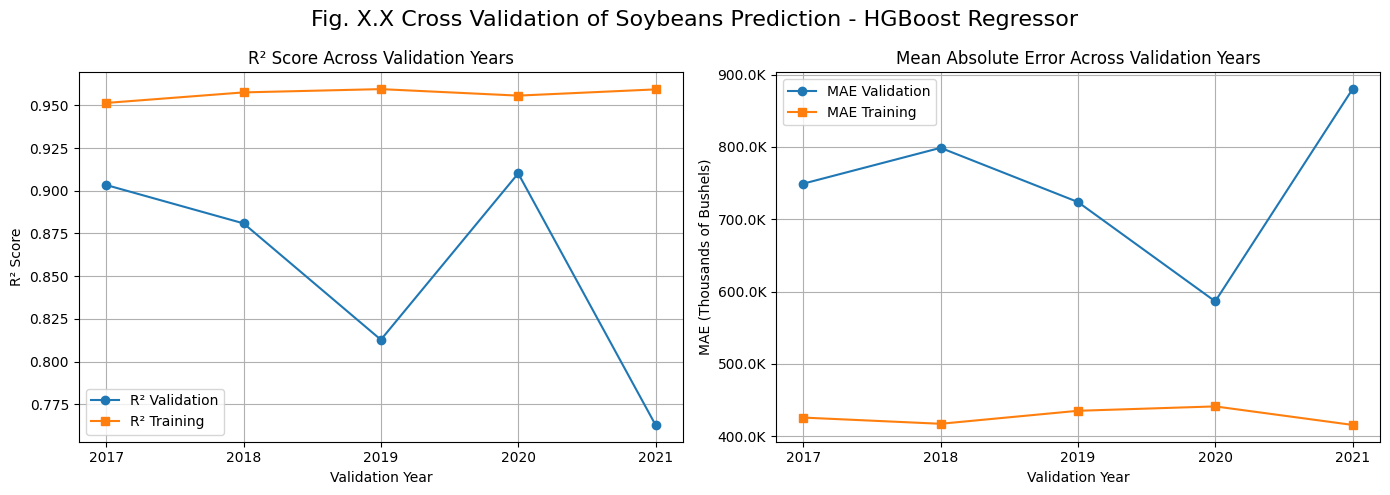

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.85
1              Avg Mean Absolute Error (MAE)  426.90K    747.55K
2         Avg Root Mean Squared Error (RMSE)  657.04K      1.15M
3  Avg Mean Absolute Percentage Error (MAPE)   31.24%     42.95%
4                              Avg Max Error    5.93M      5.50M


In [136]:

soybeans_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_soybeans['params']))
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Soybeans Prediction - HGBoost Regressor")

#### 2.5.2 Log Transformation + Standard Scaler

In [108]:
hgb_grid_search_results_soybeans_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_soybeans_log_transformed = max(hgb_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_hgb_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_hgb_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Soybeans Prediction Grid Search Result
  Best params: {'learning_rate': 0.01, 'max_iter': 500, 'max_depth': 5, 'l2_regularization': 10.0, 'min_samples_leaf': 20}
  Mean R²: 0.8577216794494756
  Mean MAE: 749400.466557919


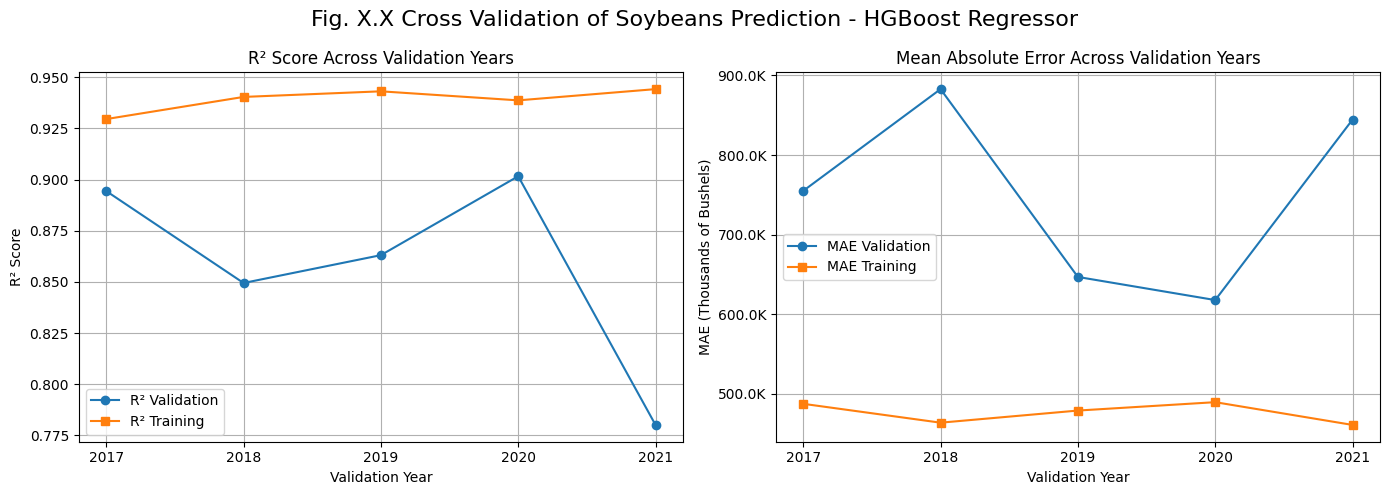

                                      Metric    Train Validation
0                               Avg R2 Score     0.94       0.86
1              Avg Mean Absolute Error (MAE)  476.19K    749.40K
2         Avg Root Mean Squared Error (RMSE)  778.11K      1.15M
3  Avg Mean Absolute Percentage Error (MAPE)   16.24%     26.35%
4                              Avg Max Error    7.32M      5.84M


In [137]:

soybeans_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_soybeans_log_transformed['params'])
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Soybeans Prediction - HGBoost Regressor")

## 3. Cotton Prediction

In [59]:
cotton_target = 'PRODUCTION, MEASURED IN 480 LB BALES'

cotton_selected_columns = [
    'Avg Temperature (C)',
    'Min Temperature (C)',
    'Heat_Stress_Day',
    'Cold_Stress_Day',
    'Wind Speed (m s**-1)',
    cotton_target,
    'harvested_area',
    'Year'
]

In [60]:
merged_cotton_dataset = pd.read_csv(merged_weather_and_cotton_production_data_dir)

complete_cotton_dataset = merged_cotton_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
selected_features_cotton_dataset = complete_cotton_dataset[cotton_selected_columns]
selected_features_cotton_dataset

,Avg Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Wind Speed (m s**-1),"PRODUCTION, MEASURED IN 480 LB BALES",harvested_area,Year
0,18.603199,-8.312000,3.700000,108.800000,5.077573,55700.0,49.161518,2017
1,18.669693,-8.272000,1.200000,100.933333,5.543904,34400.0,34.572864,2017
2,16.135538,-11.329375,3.375000,149.125000,4.815941,85400.0,63.731343,2017
3,16.506291,-13.352500,2.312500,141.375000,5.196781,163000.0,138.723404,2017
4,17.549455,-13.142273,0.636364,126.045455,5.111983,46400.0,40.630473,2017
...,...,...,...,...,...,...,...,...
665,18.380986,-12.756923,97.730769,146.730769,4.350502,21300.0,24.796275,2022
666,22.700379,-8.792500,42.083333,59.166667,6.951762,101100.0,139.640884,2022
667,20.250513,-10.844286,78.023810,103.357143,3.714269,10500.0,24.193548,2022
668,16.195158,-15.552500,55.875000,170.812500,4.302007,22000.0,52.884615,2022


In [61]:
train_set_cotton, test_set_cotton = helper.split_dataset_by_year(selected_features_cotton_dataset, 2022)
standard_scaler_cotton = StandardScaler()

In [62]:
X_test_cotton = test_set_cotton.drop(columns=[cotton_target])
y_test_cotton = test_set_cotton[cotton_target]

In [63]:
precomputed_log_transformed_cotton_data = helper.precompute_transformations_by_fold(
        train_set_cotton, cotton_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

In [101]:
precomputed_log_transformed_cotton_data

{np.int64(2017): {'train_data':      Avg Temperature (C)  Min Temperature (C)  Heat_Stress_Day  \
  116            17.938471           -13.421500        18.550000   
  117            17.842027           -13.774667         7.933333   
  118            15.507971           -15.628750         5.437500   
  119            15.800464           -16.166250         4.062500   
  120            16.747941           -14.929545         5.500000   
  ..                   ...                  ...              ...   
  568            17.741864           -19.771538        51.576923   
  569            23.211744            -5.917500        26.250000   
  570            19.759357           -15.854048        22.714286   
  571            15.786149           -20.055000        19.875000   
  572            18.212548           -19.900000        31.250000   
  
       Cold_Stress_Day  Wind Speed (m s**-1)  \
  116       130.850000              5.173854   
  117       128.333333              5.594796   
  118  

### 3.1 SGD Regressor

#### 3.1.1 Standard Scaler Only

In [64]:
sgd_grid_search_results_cotton = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_cotton = max(sgd_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_sgd_cotton['params'])
print("  Mean R²:", best_sgd_cotton['mean_r2'])
print("  Mean MAE:", best_sgd_cotton['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Cotton Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.01, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.826175126170994
  Mean MAE: 20935.600304836214


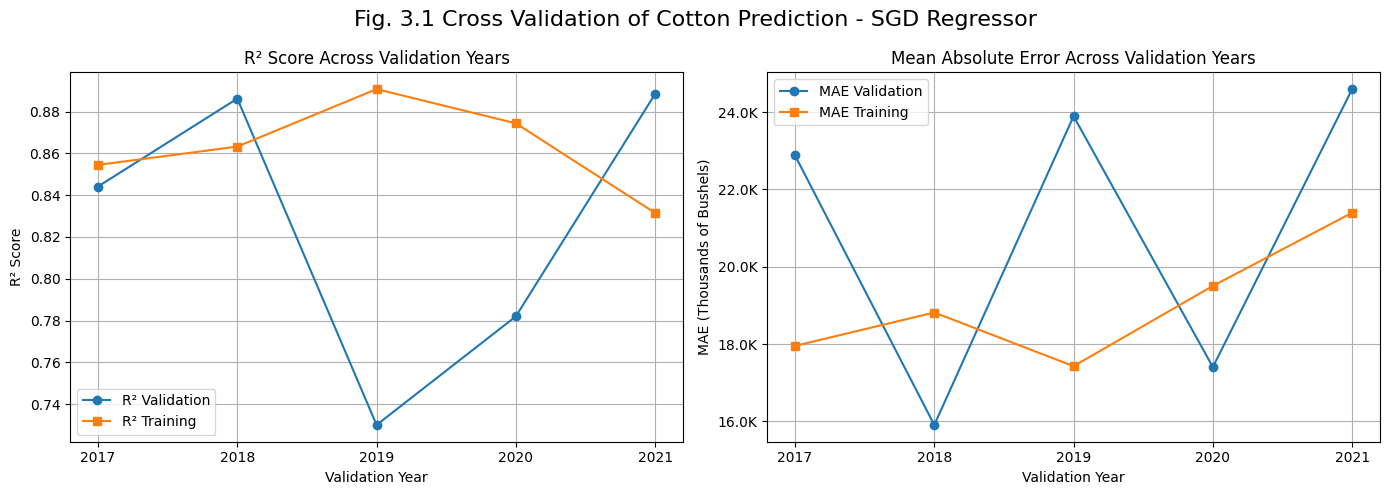

                                      Metric    Train Validation
0                               Avg R2 Score     0.86       0.83
1              Avg Mean Absolute Error (MAE)   19.02K     20.94K
2         Avg Root Mean Squared Error (RMSE)   28.53K     30.23K
3  Avg Mean Absolute Percentage Error (MAPE)   55.40%     73.09%
4                              Avg Max Error  138.45K    123.09K


In [138]:

cotton_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SGD, title="Fig. 3.1 Cross Validation of Cotton Prediction - SGD Regressor")

#### 3.1.2 Log Transformation + Standard Scaler

In [66]:
sgd_grid_search_results_cotton_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, cotton_target,
        scaler=standard_scaler_cotton, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_cotton_log_transformed = max(sgd_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_sgd_cotton_log_transformed['params'])
print("  Mean R²:", best_sgd_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_cotton_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Cotton Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.05}
  Mean R²: 0.8634739864371704
  Mean MAE: 17048.516390275792


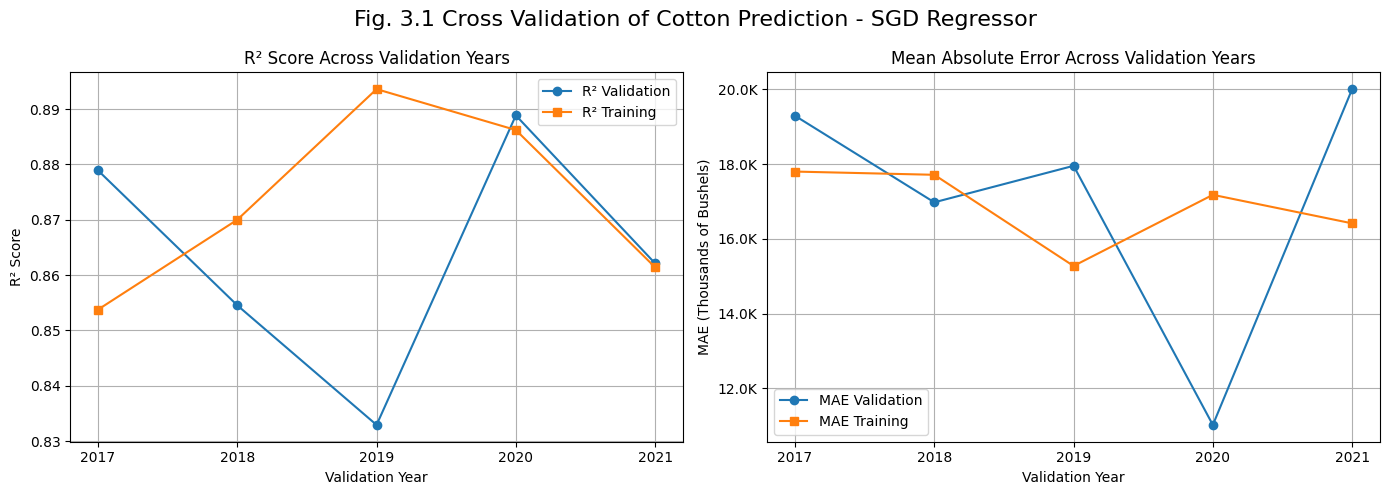

                                      Metric    Train Validation
0                               Avg R2 Score     0.87       0.86
1              Avg Mean Absolute Error (MAE)   16.87K     17.05K
2         Avg Root Mean Squared Error (RMSE)   27.49K     27.75K
3  Avg Mean Absolute Percentage Error (MAPE)   33.69%     32.78%
4                              Avg Max Error  150.59K    123.34K


In [139]:

cotton_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        model=SGDRegressor(random_state=42, **best_sgd_cotton_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 3.1 Cross Validation of Cotton Prediction - SGD Regressor")

### 3.2 SVR Regressor

#### 3.2.1 Standard Scaler Only

In [68]:

svr_grid_search_results_cotton = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_cotton = max(svr_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Cotton Prediction Grid Search Result")
print("  Best params:", best_svr_param_cotton['params'])
print("  Mean R²:", best_svr_param_cotton['mean_r2'])
print("  Mean MAE:", best_svr_param_cotton['mean_mae'])


Grid Search Process: 144/144
SVR Cotton Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 100000, 'epsilon': 50, 'gamma': 'scale'}
  Mean R²: 0.8803574139035828
  Mean MAE: 17120.34001065934


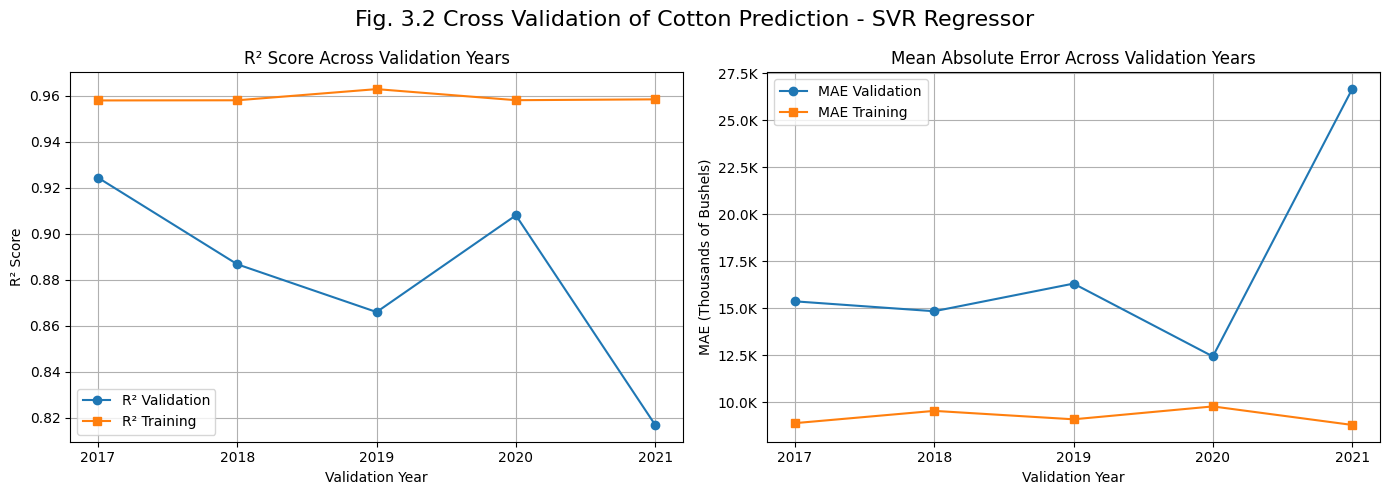

                                      Metric   Train Validation
0                               Avg R2 Score    0.96       0.88
1              Avg Mean Absolute Error (MAE)   9.22K     17.12K
2         Avg Root Mean Squared Error (RMSE)  15.68K     25.91K
3  Avg Mean Absolute Percentage Error (MAPE)  23.95%     53.38%
4                              Avg Max Error  99.31K    123.34K


In [140]:
cotton_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton,
                                                                 model=SVR(**best_svr_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SVR, title="Fig. 3.2 Cross Validation of Cotton Prediction - SVR Regressor")

#### 3.2.2 Log Transformation + Standard Scaler

In [70]:
svr_grid_search_results_cotton_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_cotton_log_transformed = max(svr_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Cotton Prediction Grid Search Result")
print("  Best params:", best_svr_param_cotton_log_transformed['params'])
print("  Mean R²:", best_svr_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_cotton_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Cotton Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 5, 'epsilon': 0.1, 'gamma': 'scale'}
  Mean R²: 0.9094449599496631
  Mean MAE: 14547.099860627179


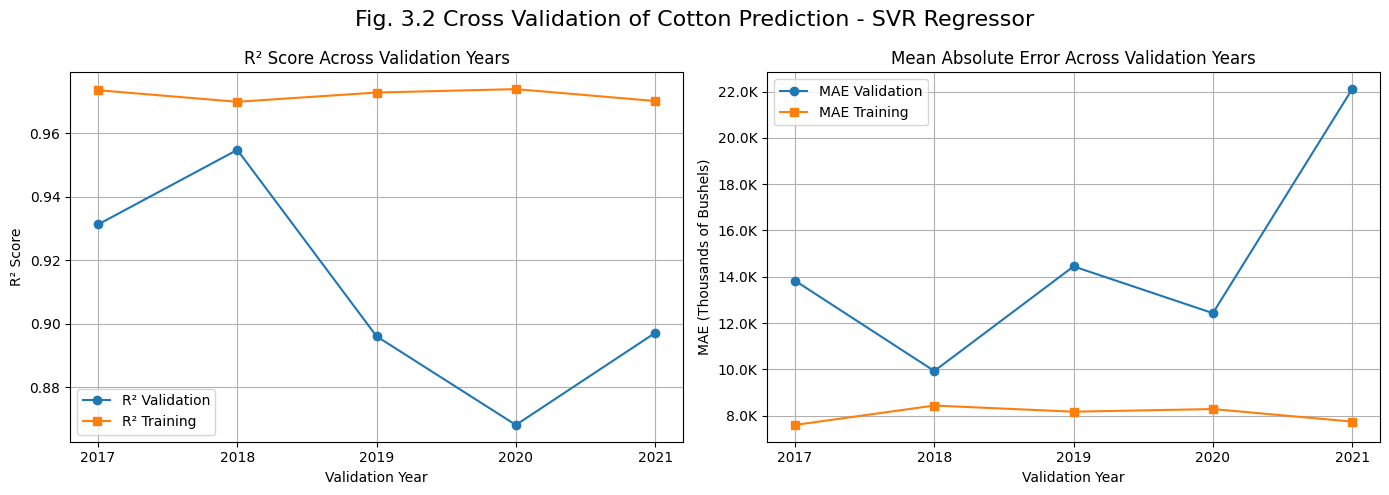

                                      Metric   Train Validation
0                               Avg R2 Score    0.97       0.91
1              Avg Mean Absolute Error (MAE)   8.04K     14.55K
2         Avg Root Mean Squared Error (RMSE)  12.92K     22.00K
3  Avg Mean Absolute Percentage Error (MAPE)  15.96%     34.25%
4                              Avg Max Error  82.17K     93.25K


In [141]:
cotton_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_cotton_data, 
    cotton_target,
    scaler=standard_scaler_cotton, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_cotton_log_transformed['params']), 
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 3.2 Cross Validation of Cotton Prediction - SVR Regressor")

### 3.3 Random Forest Regressor

#### 3.3.1 Standard Scaler Only

In [72]:
rf_grid_search_results_cotton = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_cotton = max(rf_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Cotton Prediction Grid Search Result")
print("  Best params:", best_rf_param_cotton['params'])
print("  Mean R²:", best_rf_param_cotton['mean_r2'])
print("  Mean MAE:", best_rf_param_cotton['mean_mae'])

Grid Search Process: 324/324
Random Forest Cotton Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.9019982896909543
  Mean MAE: 13917.152350482502


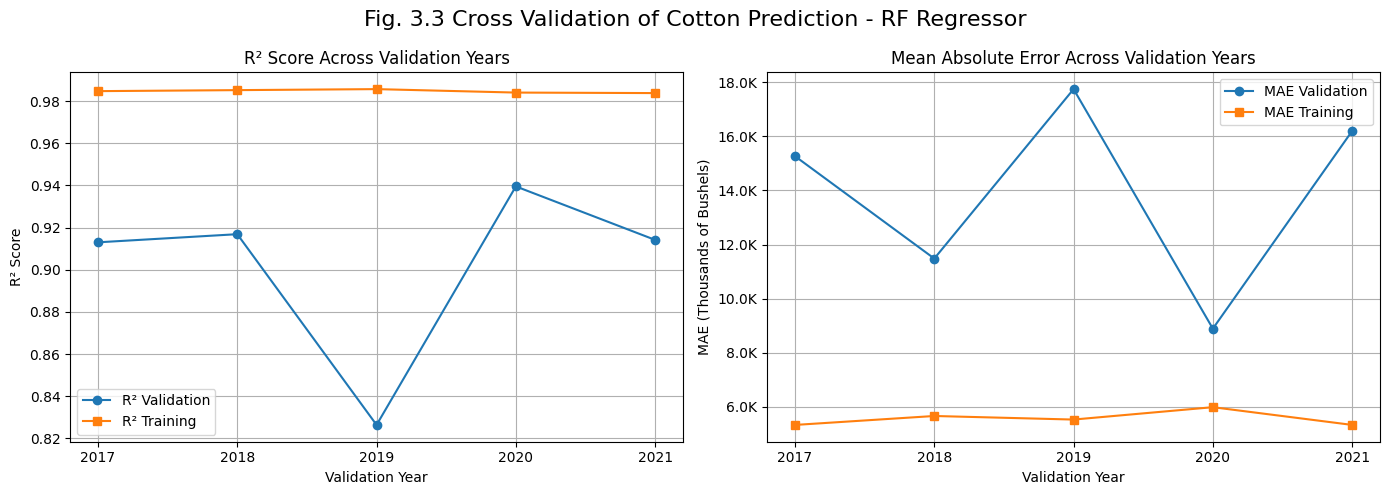

                                      Metric   Train Validation
0                               Avg R2 Score    0.98       0.90
1              Avg Mean Absolute Error (MAE)   5.56K     13.92K
2         Avg Root Mean Squared Error (RMSE)   9.57K     23.15K
3  Avg Mean Absolute Percentage Error (MAPE)  11.74%     29.32%
4                              Avg Max Error  56.29K    101.19K


In [142]:
cotton_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_RF, title="Fig. 3.3 Cross Validation of Cotton Prediction - RF Regressor")

#### 3.3.2 Log Transformation + Standard Scaler

In [74]:
rf_grid_search_results_cotton_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )
    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_cotton_log_transformed = max(rf_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Cotton Prediction Grid Search Result")
print("  Best params:", best_rf_param_cotton_log_transformed['params'])
print("  Mean R²:", best_rf_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Cotton Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.9038010662314356
  Mean MAE: 14017.708403949955


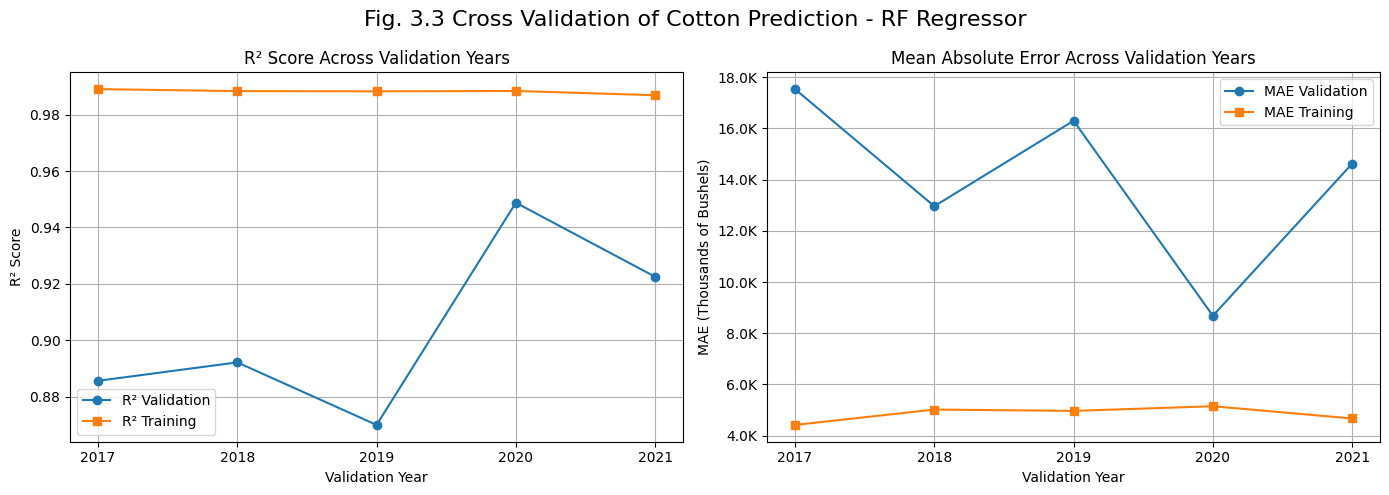

                                      Metric   Train Validation
0                               Avg R2 Score    0.99       0.90
1              Avg Mean Absolute Error (MAE)   4.85K     14.02K
2         Avg Root Mean Squared Error (RMSE)   8.40K     23.29K
3  Avg Mean Absolute Percentage Error (MAPE)   9.20%     27.59%
4                              Avg Max Error  58.32K    100.89K


In [143]:
cotton_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_cotton_data, 
    cotton_target,
    scaler=standard_scaler_cotton, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_cotton_log_transformed['params']),
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 3.3 Cross Validation of Cotton Prediction - RF Regressor")

### 3.4 MLP Regressor

#### 3.4.1 Standard Scaler Only

In [76]:
mlp_grid_search_results_cotton = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_cotton = max(mlp_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_mlp_param_cotton['params'])
print("  Mean R²:", best_mlp_param_cotton['mean_r2'])
print("  Mean MAE:", best_mlp_param_cotton['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Cotton Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.1, 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'max_iter': 30000}
  Mean R²: 0.8797421873739063
  Mean MAE: 17540.329875820673


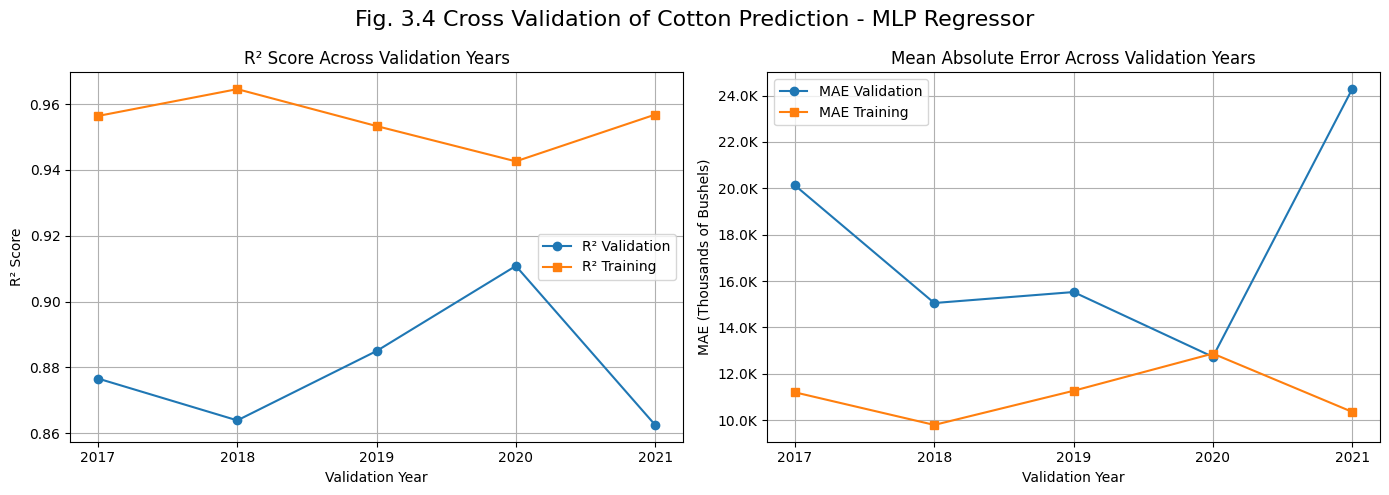

                                      Metric   Train Validation
0                               Avg R2 Score    0.95       0.88
1              Avg Mean Absolute Error (MAE)  11.10K     17.54K
2         Avg Root Mean Squared Error (RMSE)  16.45K     26.31K
3  Avg Mean Absolute Percentage Error (MAPE)  37.19%     49.96%
4                              Avg Max Error  98.07K    101.66K


In [144]:
cotton_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_MLP, title="Fig. 3.4 Cross Validation of Cotton Prediction - MLP Regressor")

#### 3.4.2 Log Transformation + Standard Scaler

In [78]:
mlp_grid_search_results_cotton_log_transformed = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_cotton_log_transformed = max(mlp_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_mlp_param_cotton_log_transformed['params'])
print("  Mean R²:", best_mlp_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 32/16
MLPRegressor Cotton Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.854149434665936
  Mean MAE: 16984.011461533224


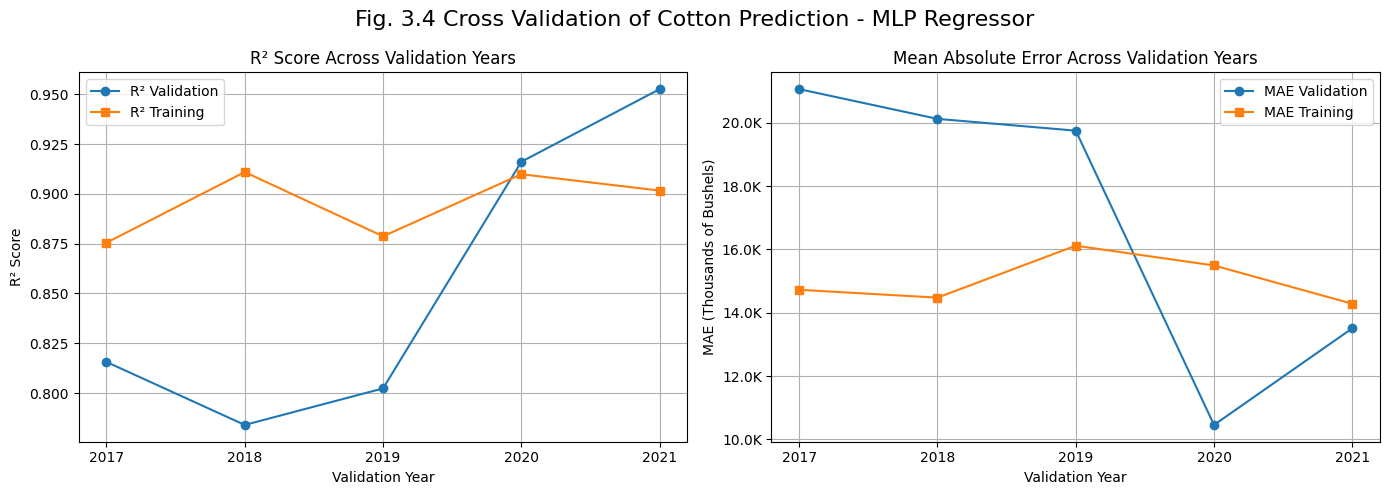

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.85
1              Avg Mean Absolute Error (MAE)   15.02K     16.98K
2         Avg Root Mean Squared Error (RMSE)   24.96K     27.64K
3  Avg Mean Absolute Percentage Error (MAPE)   27.94%     32.28%
4                              Avg Max Error  136.40K    121.47K


In [145]:
cotton_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_cotton_log_transformed['params'])
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 3.4 Cross Validation of Cotton Prediction - MLP Regressor")

### 3.5 HGBoost Regressor

#### 3.5.1 Standard Scaler Only

In [110]:
hgb_grid_search_results_cotton = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_cotton = max(hgb_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Cotton Prediction Grid Search Result")
print("  Best params:", best_hgb_param_cotton['params'])
print("  Mean R²:", best_hgb_param_cotton['mean_r2'])
print("  Mean MAE:", best_hgb_param_cotton['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Cotton Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 100, 'max_depth': 10, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.8907071564480908
  Mean MAE: 14737.205930331565


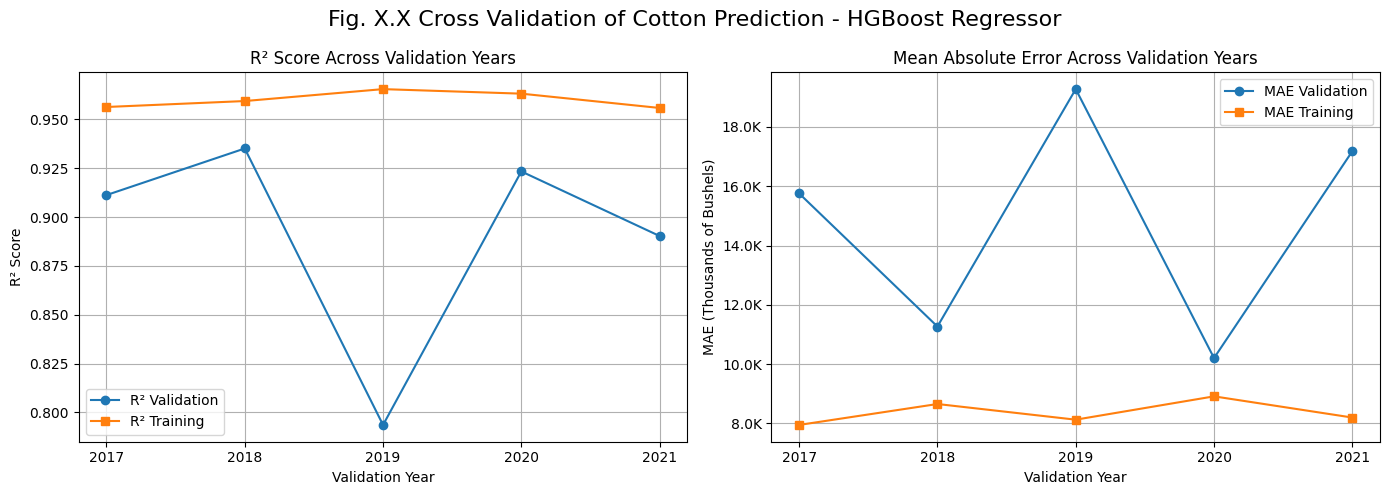

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.89
1              Avg Mean Absolute Error (MAE)    8.37K     14.74K
2         Avg Root Mean Squared Error (RMSE)   15.44K     24.26K
3  Avg Mean Absolute Percentage Error (MAPE)   20.88%     36.97%
4                              Avg Max Error  111.00K    111.74K


In [146]:

cotton_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Cotton Prediction - HGBoost Regressor")

#### 3.5.2 Log Transformation + Standard Scaler

In [112]:
hgb_grid_search_results_cotton_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_cotton_log_transformed = max(hgb_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Cotton Prediction Grid Search Result")
print("  Best params:", best_hgb_param_cotton_log_transformed['params'])
print("  Mean R²:", best_hgb_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Cotton Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 100, 'max_depth': 10, 'l2_regularization': 0.1, 'min_samples_leaf': 20}
  Mean R²: 0.8961469709312478
  Mean MAE: 14235.106531840187


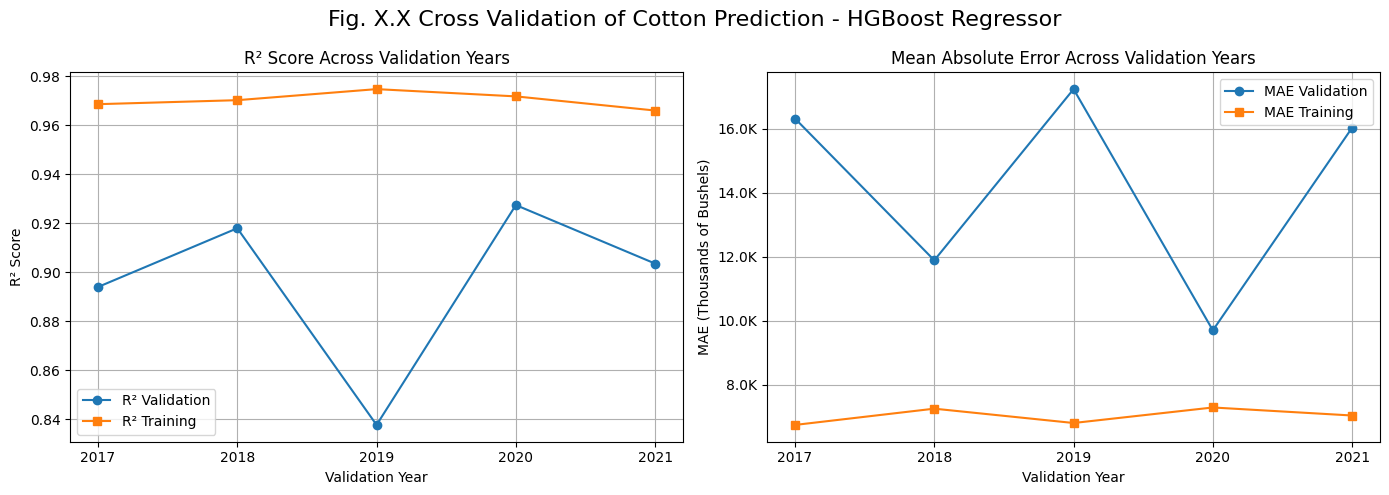

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.90
1              Avg Mean Absolute Error (MAE)    7.02K     14.24K
2         Avg Root Mean Squared Error (RMSE)   13.31K     24.07K
3  Avg Mean Absolute Percentage Error (MAPE)   13.72%     28.95%
4                              Avg Max Error  104.29K    115.93K


In [147]:

cotton_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_cotton_log_transformed['params'])
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Cotton Prediction - HGBoost Regressor")

## 4. Wheat Prediction

In [80]:
wheat_target = 'PRODUCTION, MEASURED IN BU'
wheat_selected_columns = [
    'Avg Temperature (C)',
    'Min Temperature (C)',
    'Cold_Stress_Day',
    'Low_Light_Day',
    'Wind Speed (m s**-1)',
    wheat_target,
    'harvested_area',
    'Year'
]

In [81]:
merged_wheat_dataset = pd.read_csv(merged_weather_and_wheat_production_data_dir)

complete_wheat_dataset = merged_wheat_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
selected_features_wheat_dataset = complete_wheat_dataset[wheat_selected_columns]

In [82]:
train_set_wheat, test_set_wheat = helper.split_dataset_by_year(selected_features_wheat_dataset, 2022)
standard_scaler_wheat = StandardScaler()

In [83]:
X_test_wheat = test_set_wheat.drop(columns=[wheat_target])
y_test_wheat = test_set_wheat[wheat_target]

In [84]:
precomputed_log_transformed_wheat_data = helper.precompute_transformations_by_fold(
        train_set_wheat, wheat_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 4.1 SGD Regressor

#### 4.1.1 Standard Scaler Only

In [85]:
sgd_grid_search_results_wheat = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_wheat = max(sgd_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_sgd_wheat['params'])
print("  Mean R²:", best_sgd_wheat['mean_r2'])
print("  Mean MAE:", best_sgd_wheat['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Wheat Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.005}
  Mean R²: 0.9088432334920629
  Mean MAE: 400384.17929239443


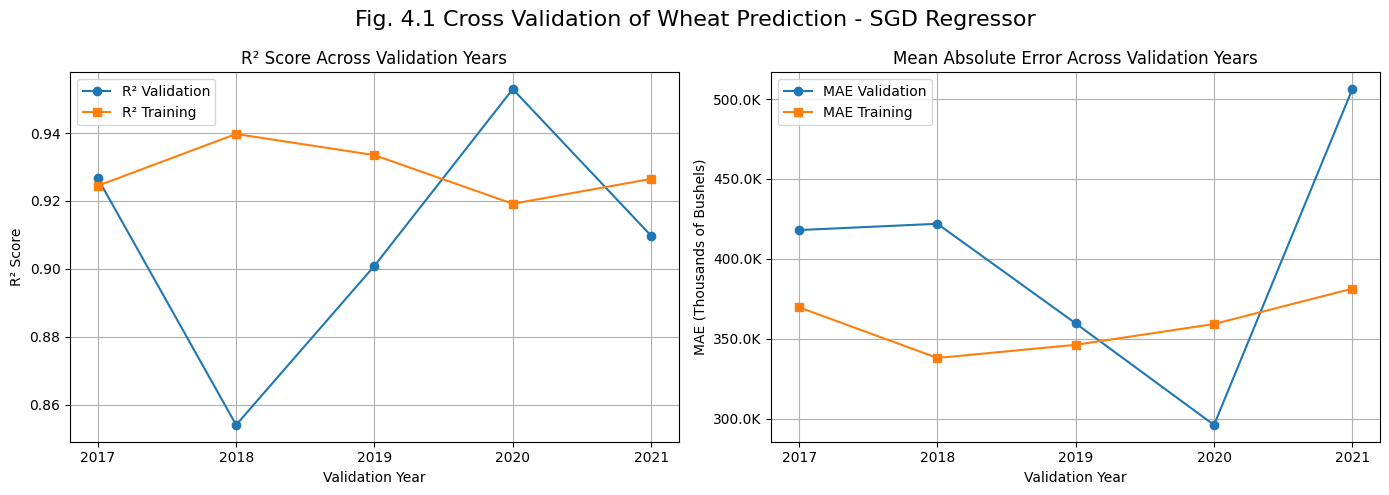

                                      Metric    Train Validation
0                               Avg R2 Score     0.93       0.91
1              Avg Mean Absolute Error (MAE)  358.89K    400.38K
2         Avg Root Mean Squared Error (RMSE)  579.73K    632.87K
3  Avg Mean Absolute Percentage Error (MAPE)   76.17%     88.39%
4                              Avg Max Error    3.97M      3.27M


In [148]:

wheat_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SGD, title="Fig. 4.1 Cross Validation of Wheat Prediction - SGD Regressor")

#### 4.1.2 Log Transformation + Standard Scaler

In [87]:
sgd_grid_search_results_wheat_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, wheat_target,
        scaler=standard_scaler_wheat, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_wheat_log_transformed = max(sgd_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_sgd_wheat_log_transformed['params'])
print("  Mean R²:", best_sgd_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_wheat_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Wheat Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.9012452879897893
  Mean MAE: 365058.72554722795


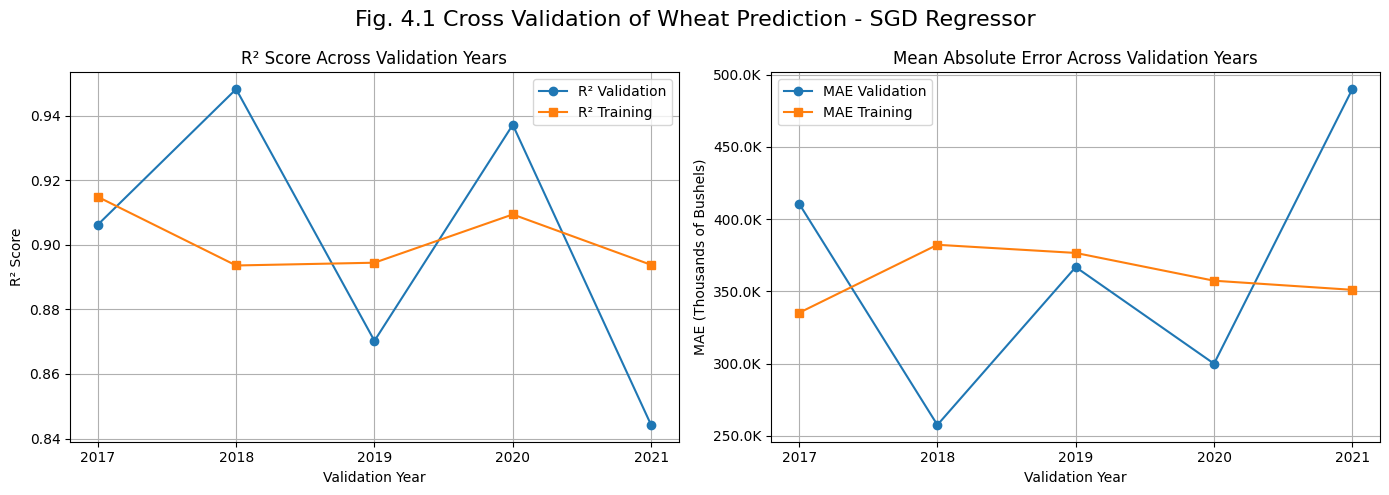

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.90
1              Avg Mean Absolute Error (MAE)  360.55K    365.06K
2         Avg Root Mean Squared Error (RMSE)  683.09K    670.33K
3  Avg Mean Absolute Percentage Error (MAPE)   30.54%     31.10%
4                              Avg Max Error    4.25M      3.65M


In [149]:

wheat_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        model=SGDRegressor(random_state=42, **best_sgd_wheat_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 4.1 Cross Validation of Wheat Prediction - SGD Regressor")

### 4.2 SVR Regressor

#### 4.2.1 Standard Scaler Only

In [89]:
svr_grid_search_results_wheat = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_wheat = max(svr_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Wheat Prediction Grid Search Result")
print("  Best params:", best_svr_param_wheat['params'])
print("  Mean R²:", best_svr_param_wheat['mean_r2'])
print("  Mean MAE:", best_svr_param_wheat['mean_mae'])


Grid Search Process: 144/144
SVR Wheat Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 50000, 'epsilon': 50}
  Mean R²: 0.9089603219521502
  Mean MAE: 362434.6536926113


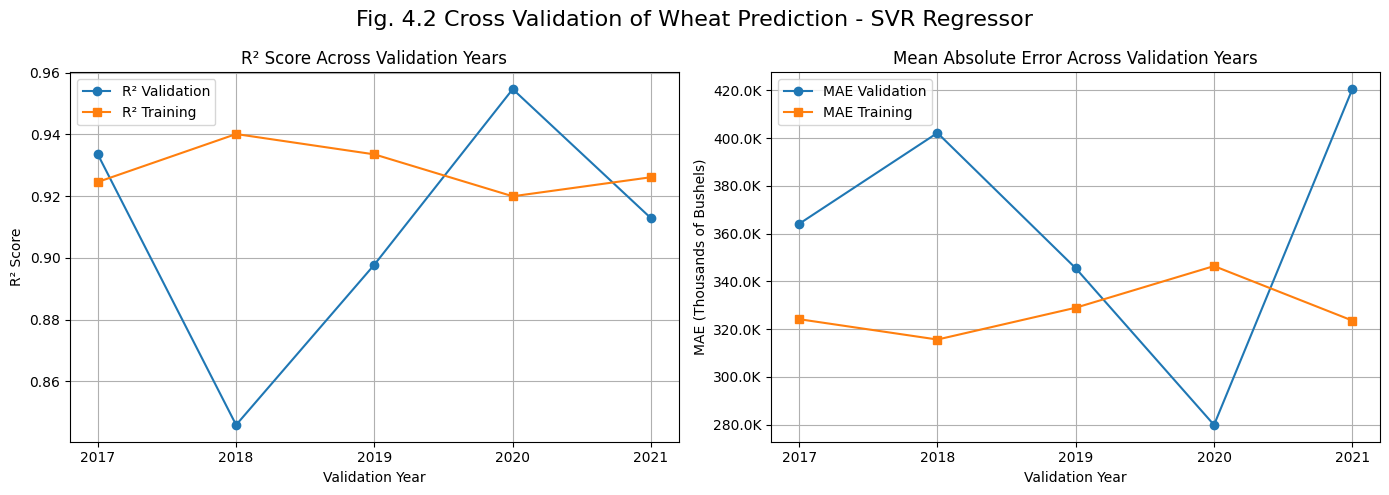

                                      Metric    Train Validation
0                               Avg R2 Score     0.93       0.91
1              Avg Mean Absolute Error (MAE)  327.75K    362.43K
2         Avg Root Mean Squared Error (RMSE)  578.85K    628.39K
3  Avg Mean Absolute Percentage Error (MAPE)   35.81%     41.13%
4                              Avg Max Error    3.96M      3.29M


In [150]:
wheat_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat,
                                                                 model=SVR(**best_svr_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SVR, title="Fig. 4.2 Cross Validation of Wheat Prediction - SVR Regressor")

#### 4.2.2 Log Transformation + Standard Scaler

In [91]:
svr_grid_search_results_wheat_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_wheat_log_transformed = max(svr_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Wheat Prediction Grid Search Result")
print("  Best params:", best_svr_param_wheat_log_transformed['params'])
print("  Mean R²:", best_svr_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_wheat_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Wheat Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 1, 'epsilon': 0.1}
  Mean R²: 0.832226298969549
  Mean MAE: 444534.4979390999


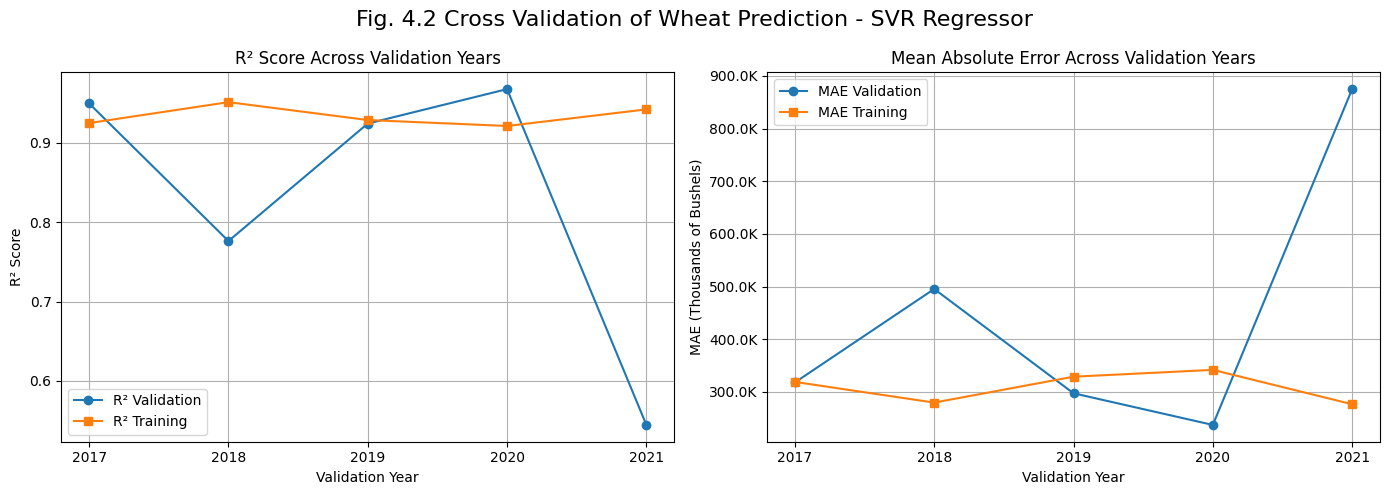

                                      Metric    Train Validation
0                               Avg R2 Score     0.93       0.83
1              Avg Mean Absolute Error (MAE)  309.10K    444.53K
2         Avg Root Mean Squared Error (RMSE)  559.20K    781.22K
3  Avg Mean Absolute Percentage Error (MAPE)   27.45%     33.11%
4                              Avg Max Error    3.68M      3.96M


In [151]:
wheat_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_wheat_data, 
    wheat_target,
    scaler=standard_scaler_wheat, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_wheat_log_transformed['params']), 
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 4.2 Cross Validation of Wheat Prediction - SVR Regressor")

### 4.3 Random Forest Regressor

#### 4.3.1 Standard Scaler Only

In [93]:
rf_grid_search_results_wheat = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_wheat = max(rf_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Wheat Prediction Grid Search Result")
print("  Best params:", best_rf_param_wheat['params'])
print("  Mean R²:", best_rf_param_wheat['mean_r2'])
print("  Mean MAE:", best_rf_param_wheat['mean_mae'])

Grid Search Process: 324/324
Random Forest Wheat Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.9035794866057799
  Mean MAE: 339664.1655018201


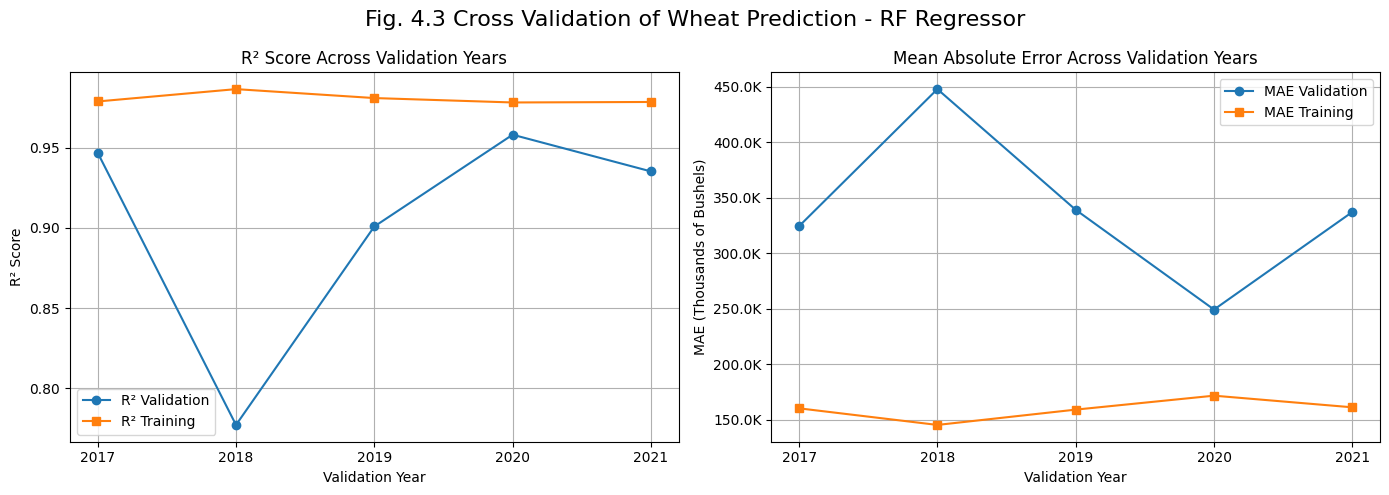

                                      Metric    Train Validation
0                               Avg R2 Score     0.98       0.90
1              Avg Mean Absolute Error (MAE)  159.54K    339.66K
2         Avg Root Mean Squared Error (RMSE)  302.29K    620.50K
3  Avg Mean Absolute Percentage Error (MAPE)   15.94%     29.44%
4                              Avg Max Error    2.64M      3.40M


In [152]:
wheat_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_RF, title="Fig. 4.3 Cross Validation of Wheat Prediction - RF Regressor")

#### 4.3.2 Log Transformation + Standard Scaler

In [95]:
rf_grid_search_results_wheat_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_wheat_log_transformed = max(rf_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Wheat Prediction Grid Search Result")
print("  Best params:", best_rf_param_wheat_log_transformed['params'])
print("  Mean R²:", best_rf_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Wheat Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}
  Mean R²: 0.8930814332167356
  Mean MAE: 362612.2235089602


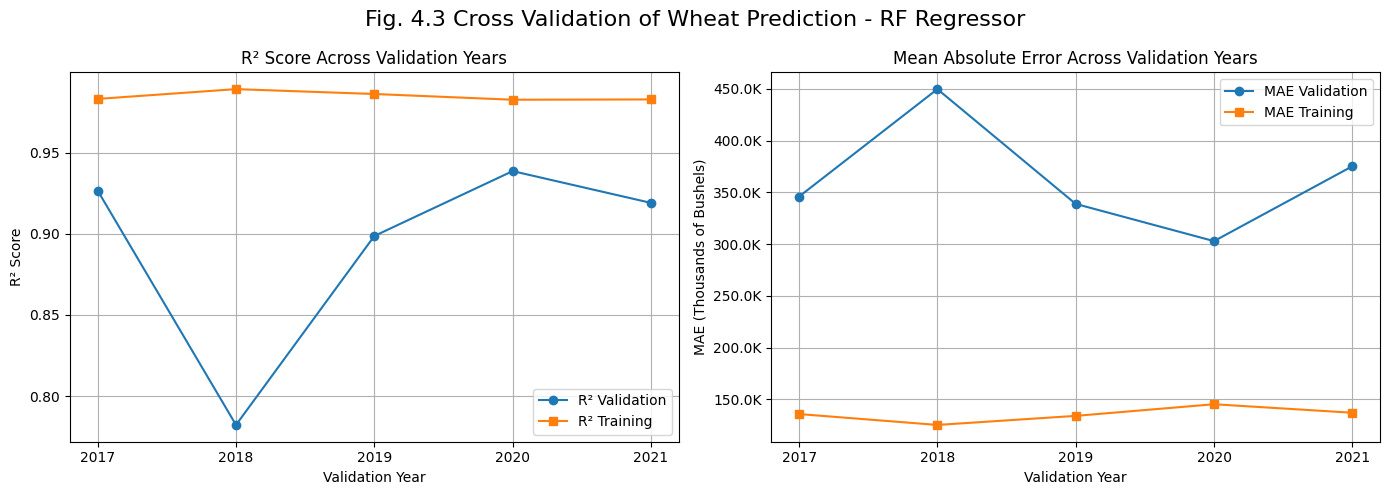

                                      Metric    Train Validation
0                               Avg R2 Score     0.98       0.89
1              Avg Mean Absolute Error (MAE)  135.54K    362.61K
2         Avg Root Mean Squared Error (RMSE)  266.18K    670.86K
3  Avg Mean Absolute Percentage Error (MAPE)   11.80%     28.04%
4                              Avg Max Error    2.13M      3.52M


In [153]:
wheat_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_wheat_data, 
    wheat_target,
    scaler=standard_scaler_wheat, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_wheat_log_transformed['params']),
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 4.3 Cross Validation of Wheat Prediction - RF Regressor")

### 4.4 MLP Regressor

#### 4.4.1 Standard Scaler Only

In [97]:
mlp_grid_search_results_wheat = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_wheat = max(mlp_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_mlp_param_wheat['params'])
print("  Mean R²:", best_mlp_param_wheat['mean_r2'])
print("  Mean MAE:", best_mlp_param_wheat['mean_mae'])

Grid Search Process: 340/16
MLPRegressor Wheat Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.8969748051148946
  Mean MAE: 400882.5528791511


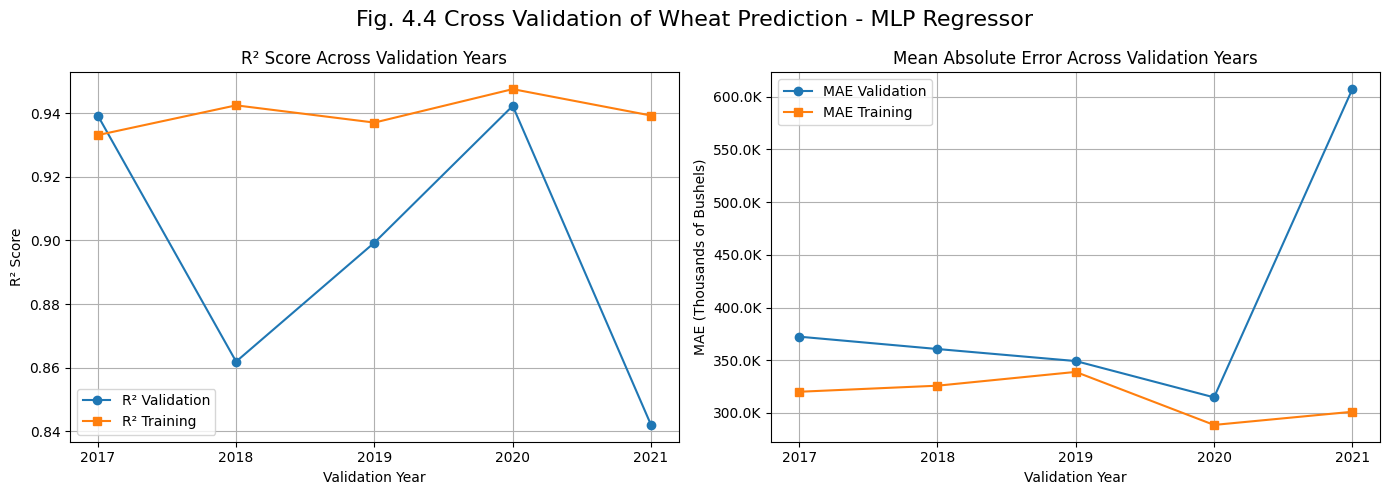

                                      Metric    Train Validation
0                               Avg R2 Score     0.94       0.90
1              Avg Mean Absolute Error (MAE)  314.94K    400.88K
2         Avg Root Mean Squared Error (RMSE)  532.49K    672.25K
3  Avg Mean Absolute Percentage Error (MAPE)   62.79%     69.71%
4                              Avg Max Error    4.01M      3.42M


In [154]:
wheat_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_MLP, title="Fig. 4.4 Cross Validation of Wheat Prediction - MLP Regressor")

#### 4.4.2 Log Transformation + Standard Scaler

In [99]:
mlp_grid_search_results_wheat_log_transformed = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_wheat_log_transformed = max(mlp_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_mlp_param_wheat_log_transformed['params'])
print("  Mean R²:", best_mlp_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 356/16
MLPRegressor Wheat Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.8717587911249993
  Mean MAE: 405965.56088433217


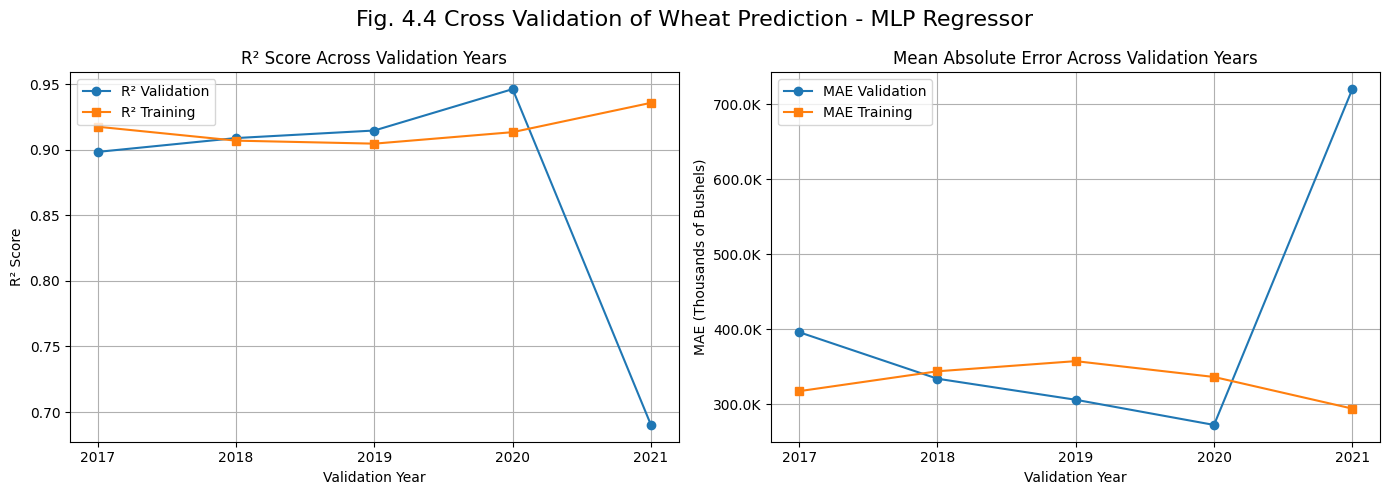

                                      Metric    Train Validation
0                               Avg R2 Score     0.92       0.87
1              Avg Mean Absolute Error (MAE)  330.17K    405.97K
2         Avg Root Mean Squared Error (RMSE)  630.14K    738.83K
3  Avg Mean Absolute Percentage Error (MAPE)   28.84%     31.80%
4                              Avg Max Error    4.41M      3.88M


In [155]:
wheat_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_wheat_log_transformed['params'])
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 4.4 Cross Validation of Wheat Prediction - MLP Regressor")

### 4.5 HGBoost Regressor

#### 4.5.1 Standard Scaler Only

In [114]:
hgb_grid_search_results_wheat = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_wheat = max(hgb_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Wheat Prediction Grid Search Result")
print("  Best params:", best_hgb_param_wheat['params'])
print("  Mean R²:", best_hgb_param_wheat['mean_r2'])
print("  Mean MAE:", best_hgb_param_wheat['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Wheat Prediction Grid Search Result
  Best params: {'learning_rate': 0.1, 'max_iter': 500, 'max_depth': 5, 'l2_regularization': 10.0, 'min_samples_leaf': 20}
  Mean R²: 0.8827827682575832
  Mean MAE: 393177.958049378


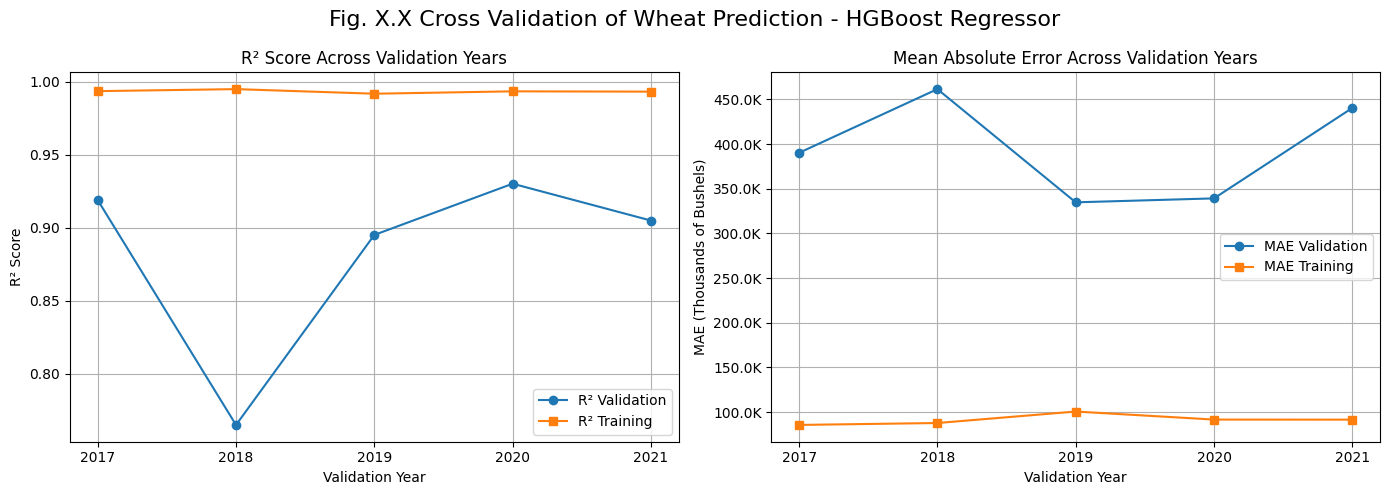

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.88
1              Avg Mean Absolute Error (MAE)   91.48K    393.18K
2         Avg Root Mean Squared Error (RMSE)  175.22K    704.54K
3  Avg Mean Absolute Percentage Error (MAPE)   22.14%     51.57%
4                              Avg Max Error    2.09M      3.77M


In [156]:

wheat_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Wheat Prediction - HGBoost Regressor")

#### 4.5.2 Log Transformation + Standard Scaler

In [116]:
hgb_grid_search_results_wheat_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_wheat_log_transformed = max(hgb_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Wheat Prediction Grid Search Result")
print("  Best params:", best_hgb_param_wheat_log_transformed['params'])
print("  Mean R²:", best_hgb_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Wheat Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 100, 'max_depth': 10, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.8778274195183269
  Mean MAE: 370119.24352800986


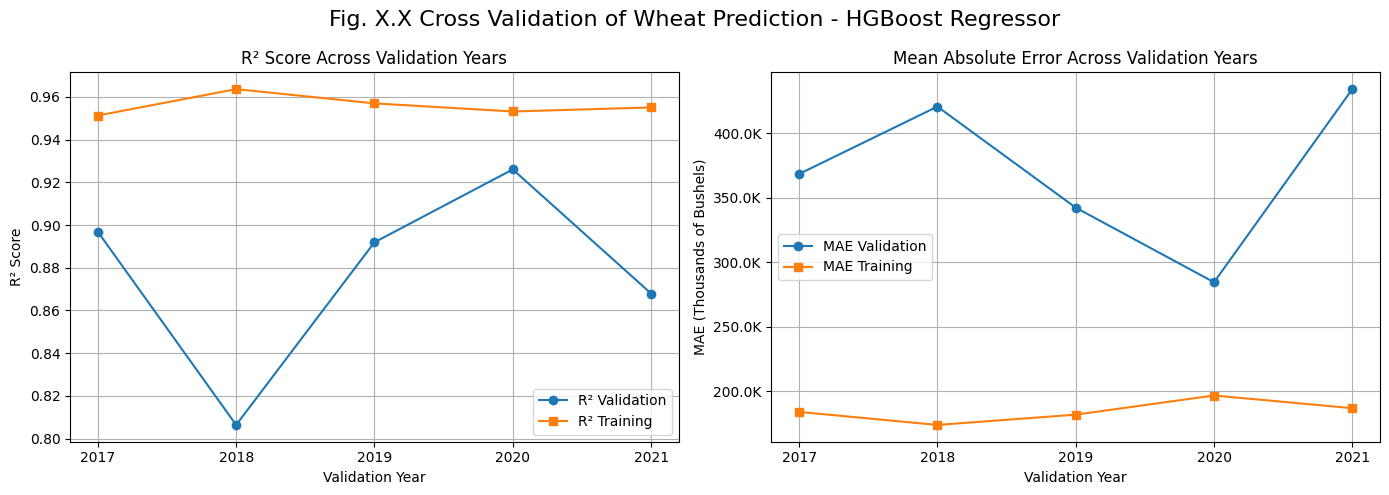

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.88
1              Avg Mean Absolute Error (MAE)  184.46K    370.12K
2         Avg Root Mean Squared Error (RMSE)  455.08K    735.99K
3  Avg Mean Absolute Percentage Error (MAPE)   14.46%     27.61%
4                              Avg Max Error    5.64M      5.48M


In [157]:

wheat_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_wheat_log_transformed['params'])
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Wheat Prediction - HGBoost Regressor")